## Deep Learning for extensive air showers reconstruction: an interpretable multi-task CNN-Transformer model for the CONDOR Observatory

This notebook mirrors the pipeline described in the paper. Multi-task CNN-Transformer for (1) gamma/hadron classification, (2) zenith angle reconstruction, (3) energy estimation.


### Contributions and Reference

- Joint multi-task learning for classification + regression (angle, energy).
- Hybrid sequence + global branch with attention.
- Physics-driven feature engineering and balanced splits.

**Paper DOI:** _Coming soon_

**Author:** _Luis F. Navarro_ / 📧 luis.navarrof@usm.cl


In [ ]:
import os
import json
import pickle
import random
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, callbacks, Input, Model
from typing import Any, Dict

import gdown
import logging
from datetime import datetime
import hashlib
import mlflow
from mlflow.models import infer_signature
import mlflow.keras

from scipy.stats import pearsonr, spearmanr, norm

from tqdm.notebook import tqdm


### Functions


In [ ]:
def compute_file_hash(path: Path, algorithm: str = "md5") -> str:
    """
    Compute the cryptographic hash of a file for integrity verification.

    Reads the file in chunks to avoid loading large files (e.g. the processed_all_data.pkl dataset) entirely into memory.

    Parameters
    ----------
    path : Path
        Path to the file to hash.
    algorithm : str, optional
        Hash algorithm supported by hashlib (e.g. 'md5', 'sha256'). Use 'md5' for speed on large files; 'sha256' for higher collision resistance. Default is 'md5'.

    Returns
    -------
    str
        Lowercase hexadecimal hash string of the file contents.
    """
    h = hashlib.new(algorithm)
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


In [ ]:
def verify_dataset_integrity(
    dataset_path: Path,
    known_versions: dict[str, str],
) -> tuple[bool, str | None]:
    """
    Verify dataset integrity by matching its hash against known versions.

    Computes the MD5 hash of the dataset file and performs a reverse lookup in the known_versions registry to identify which registered version it corresponds to, if any. This guards against silent dataset changes (e.g. updates to the Google Drive source file) that would produce different results with the same code.

    Parameters
    ----------
    dataset_path : Path
        Path to the dataset file to verify (e.g. processed_all_data.pkl).
    known_versions : dict[str, str]
        Registry mapping descriptive version names to their expected MD5
        hashes. Example:
        {"v1_300_500_800GeV_angle60": "cf21f0de988a269fb5128e0e8993f632"}.

    Returns
    -------
    tuple[bool, str | None]
        - (True, version_name) if the file hash matches a known version.
        - (False, None) if the hash is not found in the registry, indicating either a new unregistered dataset version or file corruption.
    """
    actual_hash = compute_file_hash(dataset_path)

    # Búsqueda inversa: hash calculado → nombre de versión
    version_found = next(
        (
            name
            for name, expected_hash in known_versions.items()
            if actual_hash == expected_hash
        ),
        None,
    )

    if version_found is None:
        logging.warning(
            "Dataset hash '%s' not found in known versions registry. "
            "The dataset may have changed or is a new unregistered version. "
            "Known versions: %s",
            actual_hash,
            list(known_versions.keys()),
        )
        return False, None
    logging.info(
        "Dataset integrity verified — version: '%s', hash: %s",
        version_found,
        actual_hash,
    )
    return True, version_found

In [ ]:
class F1Score(tf.keras.metrics.Metric):
    """
    Calcula la métrica F1-Score a nivel de batch.
    """

    def __init__(
        self, name: str = "f1_score", threshold: float = 0.5, **kwargs: Any
    ) -> None:
        super().__init__(name=name, **kwargs)
        self.threshold = threshold

        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(
        self, y_true: tf.Tensor, y_pred: tf.Tensor, sample_weight: Any = None
    ) -> None:
        # Lógica de actualización (usando self.threshold)
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)

        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self) -> tf.Tensor:
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
        return (
            2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
        )

    def reset_state(self) -> None:

        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)

    def get_config(self) -> dict[str, Any]:
        """Necesario para que el modelo pueda ser guardado/cargado correctamente."""
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config

### Reproducibility and Environment

- Fixed seeds (numpy, random, tensorflow).
- GPU memory growth + mixed precision.
- Paths and artifact directories.


In [ ]:
# ----------------------------- #
# Reproducibility configuration #
# ----------------------------- #
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
logging.info("Random seeds fixed — SEED=%d", SEED)
DEBUG_MODE = True  # True = usa subconjunto pequeño para pruebas rápidas
DEBUG_PERCENTAGE = 8  # porcentaje de eventos a usar en modo debug

os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    logging.warning(
        "No GPU detected — training will run on CPU and may be significantly slower"
    )
else:
    logging.info("GPUs detected: %s", [g.name for g in gpus])

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            logging.info("Memory growth enabled for %s", gpu.name)
        except RuntimeError as e:
            # RuntimeError ocurre cuando la GPU ya fue inicializada antes
            # de llamar set_memory_growth — no es fatal pero debe registrarse
            logging.warning("Could not enable memory growth for %s: %s", gpu.name, e)
        except Exception as e:
            # Cualquier otro fallo inesperado de driver o configuración
            logging.error("Unexpected error configuring %s: %s", gpu.name, e)

    try:
        tf.keras.mixed_precision.set_global_policy("mixed_float16")
        logging.info(
            "Mixed precision enabled (float16) — faster training on compatible GPUs"
        )
    except Exception as e:
        logging.warning(
            "Could not enable mixed precision, falling back to float32: %s", e
        )

2026-06-07 03:53:00,644  INFO      Random seeds fixed — SEED=42
2026-06-07 03:53:00,648  INFO      GPUs detected: ['/physical_device:GPU:0']
2026-06-07 03:53:00,650  INFO      Memory growth enabled for /physical_device:GPU:0
2026-06-07 03:53:00,652  INFO      Mixed precision enabled (float16) — faster training on compatible GPUs


### Data Source and Physics Cuts

- Monte Carlo EAS simulations for CONDOR.
- Energy bands: 3E2, 5E2, 8E2; zenith ≤ 40°; min total particles ≥ 30.
- Cached pickle download if missing.


In [ ]:
# * Se configura archivo de log con timestamp para cada ejecución, guardando tanto en consola como en un archivo dentro de pipeline_artifacts.
log_dir = Path("pipeline_artifacts/logs")
log_dir.mkdir(parents=True, exist_ok=True)
log_filename = log_dir / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(log_filename, encoding="utf-8"),
    ],
    force=True,
)

In [ ]:
# ----------------------------- #
# Paths and pipeline parameters #
# ----------------------------- #
BASE_DIR: Path = Path.cwd()
CACHE_FILE = BASE_DIR / "processed_all_data.pkl"

DATASET_VERSIONS: dict[str, str] = {
    "v1_(300_500_800GeV_angle60)": "cf21f0de988a269fb5128e0e8993f632",
    # "v2_(300_500_800GeV_1TeV_angle60)": "...",
}

if not CACHE_FILE.exists():
    url = "https://drive.google.com/uc?id=1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz"
    gdown.download(url, str(CACHE_FILE), quiet=False)
is_valid, dataset_version = verify_dataset_integrity(
    CACHE_FILE,
    DATASET_VERSIONS,
)
ARTIFACTS_DIR: Path = BASE_DIR / "pipeline_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_EXPERIMENT_NAME = "CONDOR_EAS_Reconstruction"
mlflow_tracking_uri: Path = ARTIFACTS_DIR / "mlruns"
mlflow_tracking_uri.mkdir(parents=True, exist_ok=True)
MLFLOW_TRACKING_URI = mlflow_tracking_uri.resolve().as_uri()

ENERGY_FILTER = ("3E2", "5E2", "8E2")
ANGLE_MAX = 40.0  # Oficial (al 04 de Mayo del 2026) es 40.
MIN_TOTAL_PARTICLES = 30  # Oficial (al 04 de Mayo del 2026) son 30.
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15  # test will be 0.15 (remaining)
BATCH_SIZE = 32
EPOCHS = 100

sns.set_context("poster")
sns.set_style("ticks")


logging.info("Model saved at: %s", BASE_DIR)
logging.info("Cache file: %s", CACHE_FILE)
logging.info("Artifacts directory: %s", ARTIFACTS_DIR)

2026-06-07 03:53:00,727  DEBUG     Starting new HTTPS connection (1): drive.google.com:443
2026-06-07 03:53:01,781  DEBUG     https://drive.google.com:443 "GET /uc?id=1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz HTTP/1.1" 200 None
2026-06-07 03:53:02,032  DEBUG     https://drive.google.com:443 "GET /uc?id=1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz&confirm=t&uuid=2ca5a590-cd87-4de9-a1d6-831fa3d2e725 HTTP/1.1" 303 0
2026-06-07 03:53:02,035  DEBUG     Starting new HTTPS connection (1): doc-0o-1s-docs.googleusercontent.com:443
2026-06-07 03:53:03,376  DEBUG     https://doc-0o-1s-docs.googleusercontent.com:443 "GET /docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/vhia0vb05tour10ti46ibfgf6gjdt9o8/1780818750000/09682235841852738828/*/1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz?uuid=2ca5a590-cd87-4de9-a1d6-831fa3d2e725 HTTP/1.1" 200 397099279
Downloading...
From (original): https://drive.google.com/uc?id=1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz
From (redirected): https://drive.google.com/uc?id=1Z6EqKXUzKrlxIYcbYg1bPfNkNhfP6Pgz&con

In [ ]:
# / ── Metadata de configuración inicial ──────────────────────────────────────────
metadata = {
    "run_timestamp": datetime.now().isoformat(),
    "seed": SEED,
    "debug_mode": DEBUG_MODE,
    "filters": {
        "energies_used": list(ENERGY_FILTER),
        "angle_max_deg": ANGLE_MAX,
        "min_total_particles": MIN_TOTAL_PARTICLES,
    },
}
logging.info("Initial configuration: %s", json.dumps(metadata, indent=2))

2026-06-07 03:53:11,392  INFO      Initial configuration: {
  "run_timestamp": "2026-06-07T03:53:11.391097",
  "seed": 42,
  "debug_mode": true,
  "filters": {
    "energies_used": [
      "3E2",
      "5E2",
      "8E2"
    ],
    "angle_max_deg": 40.0,
    "min_total_particles": 30
  }
}


In [ ]:
# Configuración inicial
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Al asignar set_experiment a una variable, obtenemos sus metadatos (incluyendo su ID)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

# 1. Consultamos si existe alguna sesión activa "zombie" en memoria
active_run = mlflow.active_run()

if active_run:
    active_run_id = active_run.info.run_id
    active_exp_id = active_run.info.experiment_id
    active_run_name = active_run.data.tags.get("mlflow.runName", "Sin_Nombre")

    # 2. Comprobamos si el run activo pertenece a nuestro experimento actual
    if active_exp_id == experiment.experiment_id:
        logging.warning(
            "Se detectó un run activo previo en este experimento "
            "(Nombre: %s | ID: %s). "
            "Se cerrará automáticamente para evitar conflictos.",
            active_run_name,
            active_run_id,
        )
    else:
        logging.warning(
            "Se detectó un run activo de un experimento distinto "
            "(Exp ID: %s | Run ID: %s). Cerrándolo por seguridad.",
            active_exp_id,
            active_run_id,
        )

    # 3. Cerramos el run activo para liberar el bloqueo
    mlflow.end_run()

# 4. Ahora es 100% seguro iniciar el nuevo run
run_name = f"cnn_transformer_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
mlflow_run = mlflow.start_run(run_name=run_name)

logging.info(
    "Nuevo run de MLflow iniciado con éxito: %s (ID: %s)",
    run_name,
    mlflow_run.info.run_id,
)
mlflow.set_tag("researcher", "Alan")  # ¿Quién corrió esto?
mlflow.set_tag("stage", "exploracion")  # ¿Es prueba o es el final?
mlflow.set_tag("data_balance", "stratified")  # Técnica usada
mlflow.set_tag("model_architecture", "CNN+Trans")  # Resumen rápido

2026/06/07 03:53:11 INFO mlflow.tracking.fluent: Experiment with name 'CONDOR_EAS_Reconstruction' does not exist. Creating a new experiment.
2026-06-07 03:53:11,629  DEBUG     Popen(['git', 'version'], cwd=d:\OneDrive - Universidad Técnica Federico Santa María\CONDOR_OD\Tesis\CONDOR_MCDropout_XAI, stdin=None, shell=False, universal_newlines=False)
2026-06-07 03:53:11,690  DEBUG     Popen(['git', 'version'], cwd=d:\OneDrive - Universidad Técnica Federico Santa María\CONDOR_OD\Tesis\CONDOR_MCDropout_XAI, stdin=None, shell=False, universal_newlines=False)
2026-06-07 03:53:11,773  DEBUG     sys.platform='win32', git_executable='git'
2026-06-07 03:53:11,893  INFO      Nuevo run de MLflow iniciado con éxito: cnn_transformer_20260607_035311 (ID: 9783ec271a69483a867271662711b396)


In [ ]:
# ----------------------------- #
# Load from pickle              #
# ----------------------------- #
def load_dataset_from_cache(cache_path: Path) -> pd.DataFrame:
    """
    Load the preprocessed dataset from a pickle cache file.

    Parameters
    ----------
    cache_path : Path
        Path to the pickle file containing the preprocessed dataset.
        Must contain the columns: shower_data, angle, label, energy,
        total_particles, max_time.

    Returns
    -------
    pd.DataFrame
        DataFrame with the full dataset, index reset.

    Raises
    ------
    FileNotFoundError
        If the cache file does not exist at the given path.
    ValueError
        If the pickle contains an unsupported type or is missing
        required columns.
    """
    if not cache_path.exists():
        raise FileNotFoundError(
            f"{cache_path} not found. Regenerate the pickle before running the pipeline."
        )
    with cache_path.open("rb") as fh:
        data = pickle.load(fh)
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    elif isinstance(data, dict):
        df = pd.DataFrame(data)
    else:
        raise ValueError("Unsupported cache format.")
    required_cols = {
        "shower_data",
        "angle",
        "label",
        "energy",
        "total_particles",
        "max_time",
    }
    if not required_cols.issubset(df.columns):
        raise ValueError("The pickle does not contain all required columns.")
    return df.reset_index(drop=True)


df_full = load_dataset_from_cache(CACHE_FILE)

df_full = df_full[
    (df_full["energy"].isin(ENERGY_FILTER))
    & (df_full["angle"] <= ANGLE_MAX)
    & (df_full["total_particles"] >= MIN_TOTAL_PARTICLES)
].reset_index(drop=True)
logging.info(
    "Dataset loaded and filtered: %d events remain after applying energy, angle, and particle count filters.",
    len(df_full),
)
if df_full.empty:
    raise RuntimeError("No events found after filtering by energy / angle / particles.")

if DEBUG_MODE:
    df_full = df_full.sample(
        n=min(len(df_full) * DEBUG_PERCENTAGE // 100, len(df_full)),
        random_state=SEED,
    ).reset_index(drop=True)
    logging.warning(
        "DEBUG_MODE active — using %d events out of full dataset. "
        "Results are NOT representative.",
        len(df_full),
    )

df_full["idx"] = df_full.index

2026-06-07 03:53:12,951  INFO      Dataset loaded and filtered: 96988 events remain after applying energy, angle, and particle count filters.
2026-06-07 03:53:12,992  WARNING   DEBUG_MODE active — using 7759 events out of full dataset. Results are NOT representative.


In [ ]:
df_full.head()

,shower_data,angle,label,energy,total_particles,max_time,idx
0,"[[24.0, 0.0, 3.0, -22.896103, -2.0488346, -21....",0.0,0,8E2,83,81,0
1,"[[2.0, 0.0, 1.0, -34.3238, -21.163568, -38.25,...",16.0,1,5E2,87,111,1
2,"[[6.0, 7.0, 1.0, -42.289383, 10.726421, -38.25...",8.0,1,8E2,207,118,2
3,"[[2.0, 14.0, 1.0, -39.52421, -19.37599, -38.25...",22.0,1,5E2,251,181,3
4,"[[36.0, 13.0, 1.0, -15.760957, 16.430483, -12....",24.0,1,8E2,37,104,4


In [ ]:
df_full.at[1, "shower_data"]

array([[ 2.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        -3.43237991e+01, -2.11635685e+01, -3.82500000e+01,
        -2.25000000e+01,  1.07905410e-01,  5.10000000e+01],
       [ 3.00000000e+00,  1.00000000e+00,  2.00000000e+00,
        -3.60741501e+01, -1.52777596e+01, -3.82500000e+01,
        -1.35000000e+01,  1.77560132e-02,  5.10000000e+01],
       [ 1.40000000e+01,  2.00000000e+00,  1.00000000e+00,
        -3.11113873e+01, -1.60259199e+00, -2.97500000e+01,
        -4.50000000e+00,  7.02528894e-01,  5.10000000e+01],
       [ 1.30000000e+01,  3.00000000e+00,  1.00000000e+00,
        -3.12306519e+01, -1.63169956e+01, -2.97500000e+01,
        -1.35000000e+01,  5.80693632e-02,  5.10000000e+01],
       [ 1.50000000e+01,  3.00000000e+00,  1.00000000e+00,
        -3.14643707e+01,  6.56241775e-01, -2.97500000e+01,
         4.50000000e+00,  1.40883354e-02,  5.10000000e+01],
       [ 1.40000000e+01,  3.00000000e+00,  1.00000000e+00,
        -3.03537598e+01, -5.11767268e-01, -2.975000

### Description of CONDOR Dataset Variables

Below are the variables used in this notebook, originating from simulated extensive air showers (EAS) under the CONDOR observatory conditions. These variables are divided into sequence features (individual hits), global event features, and target variables.

| Variable                  | Description                                                                                                    |
| :------------------------ | :------------------------------------------------------------------------------------------------------------- |
| **`shower_data`**         | Raw sequence of hits recorded by the detectors. This is the main input for the convolutional/recurrent branch. |
| `detector_id`             | Unique identifier of the detector that registered the signal.                                                  |
| `x_center`, `y_center`    | Spatial coordinates (in meters) of the center of the activated detector.                                       |
| `t_bin`                   | Discretized time bin when the signal was recorded in the detector.                                             |
| `particle_count`          | Number of secondary particles detected in the detector at that instant.                                        |
| `total_energy` (hit)      | Energy deposited in the specific detector during the hit.                                                      |
| **`total_particles`**     | Total sum of particles detected across the entire array (global feature).                                      |
| **`active_detectors`**    | Number of unique detectors activated during the event (global feature).                                        |
| **`max_time / duration`** | Total temporal duration of the event in the array (global feature).                                            |
| **`energy_central`**      | Accumulated energy specifically in the 16 central detectors of the array (global feature).                     |
| **`label`**               | Classification label: Type of primary particle (Photon $\gamma$ vs Proton/Hadron).                             |
| **`angle`**               | Zenith angle of the incoming primary particle (in degrees). Regression target variable.                        |
| **`energy`**              | Energy of the primary particle (in GeV). Regression target variable (e.g., 300, 500, 800 GeV).                 |

> **Note:** Sequence variables (`detector_id`, `t_bin`, etc.) are processed as time series, while global variables (`total_particles`, etc.) are injected directly into the dense layers of the hybrid model.


### Detector Geometry Reconstruction

- Map detector_id → (x_center, y_center).
- Save catalog for spatial features.


In [ ]:
# ----------------------------- #
# Catálogo de detectores        #
# ----------------------------- #
def build_detector_catalog(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a catalog of unique detectors with their spatial coordinates.

    Extracts detector_id, x_center, and y_center from the raw shower_data
    sequences and deduplicates by detector_id, producing a reference table
    of the physical array geometry.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a shower_data column where each entry is an
        array of shape (n_hits, n_raw_features). Columns 0, 5, and 6
        correspond to detector_id, x_center, and y_center respectively.

    Returns
    -------
    pd.DataFrame
        Catalog with columns [detector_id, x_center, y_center], one row
        per unique detector, sorted by detector_id. Returns an empty
        DataFrame if no valid sequences are found.
    """
    positions = []
    for seq in df["shower_data"]:
        arr = np.asarray(seq, dtype=np.float32)
        if arr.size == 0:
            continue
        positions.append(arr[:, [0, 5, 6]])  # detector_id, x_center, y_center
    if not positions:
        return pd.DataFrame(columns=["detector_id", "x_center", "y_center"])
    catalog = (
        pd.DataFrame(
            np.vstack(positions), columns=["detector_id", "x_center", "y_center"]
        )
        .drop_duplicates(subset=["detector_id"])
        .sort_values("detector_id")
        .reset_index(drop=True)
    )
    catalog["detector_id"] = catalog["detector_id"].astype(int)
    return catalog


detector_catalog = build_detector_catalog(df_full)
detector_catalog.to_csv(ARTIFACTS_DIR / "detector_catalog.csv", index=False)

In [ ]:
detector_catalog

,detector_id,x_center,y_center
0,0,-38.250000,-40.50
1,1,-38.250000,-31.50
2,2,-38.250000,-22.50
3,3,-38.250000,-13.50
4,4,-38.250000,-4.50
...,...,...,...
115,115,50.400002,-13.50
116,116,50.400002,13.50
117,117,50.400002,40.50
118,118,50.400002,-53.75


### Balancing Strategy

- Undersample/oversample by (label, angle, energy) to remove spectral/geom biases.
- Target = median group size.


In [ ]:
def balance_by_group(
    df: pd.DataFrame, group_cols, random_state: int
) -> tuple[pd.DataFrame, int]:
    """
    Balance the dataset by resampling each group to the median group size.

    Groups are defined by the combination of values in group_cols. Groups
    smaller than the target are oversampled with replacement; groups larger
    than the target are undersampled without replacement. This strategy
    removes spectral and geometric biases introduced by unequal simulation
    statistics across (label, angle, energy) combinations.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame to balance.
    group_cols : sequence of str
        Column names used to define groups (e.g. ['label', 'angle', 'energy']).
    random_state : int
        Random seed for reproducible sampling.

    Returns
    -------
    tuple[pd.DataFrame, int]
        - Balanced and shuffled DataFrame.
        - Target sample size per group (median of original group sizes).

    Raises
    ------
    RuntimeError
        If no non-empty groups are found after grouping.
    """
    counts = df.groupby(list(group_cols)).size()
    counts = counts[counts > 0]
    if counts.empty:
        raise RuntimeError("No groups available for balancing.")
    target = int(counts.median())
    balanced_parts = []
    for _, group in df.groupby(list(group_cols)):
        replace = len(group) < target
        balanced_parts.append(
            group.sample(n=target, replace=replace, random_state=random_state)
        )
    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1.0, random_state=random_state).reset_index(
        drop=True
    )
    return balanced_df, target


df_balanced, target_per_group = balance_by_group(
    df_full,
    group_cols=("label", "angle", "energy"),
    random_state=SEED,
)

In [ ]:
# / ── Metadata post balanceo ─────────────────────────────────────────────────────
metadata["dataset"] = {
    "balance_target_per_group": target_per_group,
    "num_events_total": int(len(df_balanced)),
    "cache_file": str(CACHE_FILE),
    "hash_md5": compute_file_hash(CACHE_FILE),
    "version": dataset_version,
    "hash_verified": is_valid,
}
logging.info(
    "Dataset balanced: %d events total, target %d per group. Version: %s, Hash valid: %s",
    len(df_balanced),
    target_per_group,
    dataset_version,
    is_valid,
)

2026-06-07 03:53:14,423  INFO      Dataset balanced: 5796 events total, target 46 per group. Version: v1_(300_500_800GeV_angle60), Hash valid: True


In [ ]:
display(df_balanced)

,shower_data,angle,label,energy,total_particles,max_time,idx
0,"[[7.0, 19.0, 1.0, -37.433258, 18.934685, -38.2...",24.0,1,8E2,127,273,6712
1,"[[112.0, 0.0, 1.0, -50.935238, 15.420222, -50....",18.0,1,5E2,67,131,7047
2,"[[1.0, 20.0, 1.0, -39.252735, -34.785046, -38....",36.0,0,3E2,51,169,1495
3,"[[6.0, 13.0, 1.0, -41.03735, 15.897345, -38.25...",34.0,0,5E2,60,189,2957
4,"[[10.0, 42.0, 1.0, -31.300209, -37.052036, -29...",32.0,1,3E2,51,159,1607
...,...,...,...,...,...,...,...
5791,"[[1.0, 4.0, 1.0, -41.991978, -29.02629, -38.25...",12.0,1,5E2,206,142,7636
5792,"[[112.0, 0.0, 1.0, -53.861515, 13.245796, -50....",32.0,1,5E2,96,190,5423
5793,"[[111.0, 4.0, 1.0, -51.635674, -10.401351, -50...",32.0,1,8E2,39,213,2101
5794,"[[108.0, 8.0, 1.0, -48.269527, -49.62904, -50....",36.0,1,3E2,109,182,3235


### Distribution Checks

- Histograms for label, angle, energy (pre/post balance).
- Cross-table summaries.


2026-06-07 03:53:14,930  DEBUG     Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-07 03:53:14,934  DEBUG     Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-07 03:53:14,941  DEBUG     findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=24.0.
2026-06-07 03:53:14,945  DEBUG     findfont: score(FontEntry(fname='c:\\Users\\alanz\\miniconda3\\envs\\condor-cnn-trans\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 2.05
2026-06-07 03:53:14,948  DEBUG     findfont: score(FontEntry(fname='c:\\Users\\alanz\\miniconda3\\envs\\condor-cnn-trans\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-07 03:53:14,951  DEBUG     findfon

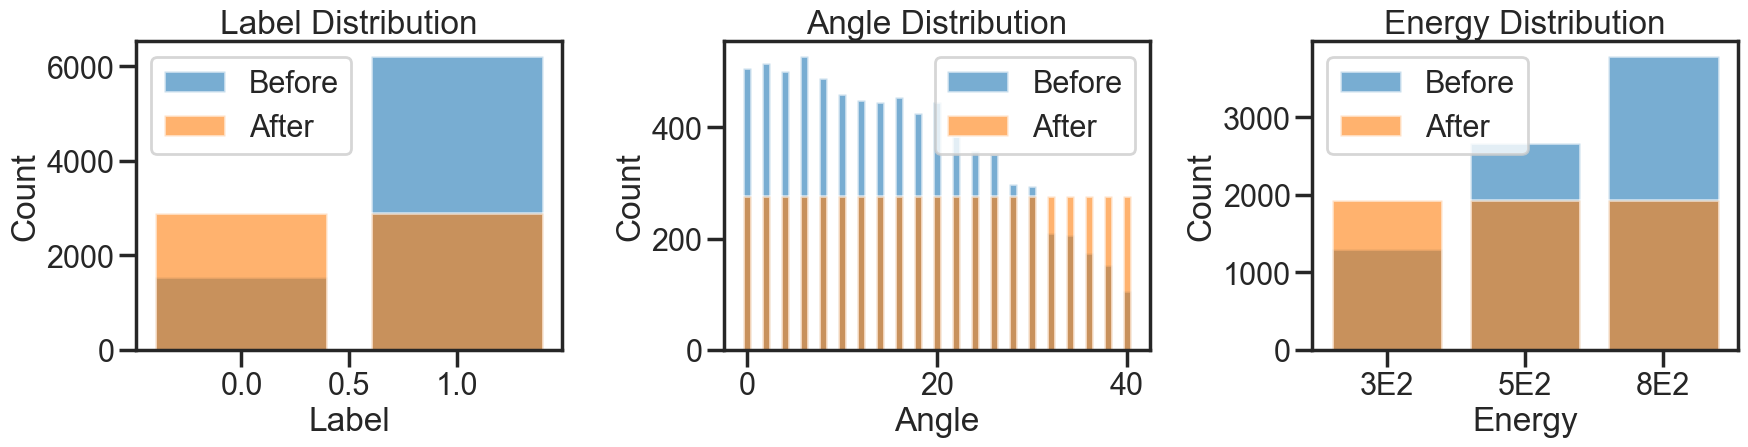

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Before balancing
df_full_counts = {
    "label": df_full["label"].value_counts().sort_index(),
    "angle": df_full["angle"].value_counts().sort_index(),
    "energy": df_full["energy"].value_counts().sort_index(),
}

# After balancing
df_balanced_counts = {
    "label": df_balanced["label"].value_counts().sort_index(),
    "angle": df_balanced["angle"].value_counts().sort_index(),
    "energy": df_balanced["energy"].value_counts().sort_index(),
}

features = ["label", "angle", "energy"]
titles = ["Label", "Angle", "Energy"]

for i, (feature, title) in enumerate(zip(features, titles)):
    ax = axes[i]
    ax.bar(
        df_full_counts[feature].index,
        df_full_counts[feature].values,
        alpha=0.6,
        label="Before",
    )
    ax.bar(
        df_balanced_counts[feature].index,
        df_balanced_counts[feature].values,
        alpha=0.6,
        label="After",
    )
    ax.set_title(f"{title} Distribution")
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()
mlflow.log_figure(fig, "graficos/distribution_summary.png")

In [ ]:
def balance_summary(df_pre: pd.DataFrame, df_post: pd.DataFrame) -> None:
    """
    Display a cross-tabulation of event counts before and after balancing.

    Groups events by (energy, label, angle) and pivots angle as columns, producing a side-by-side comparison of the dataset distribution before and after the balancing step. Output is rendered via IPython display.

    Parameters
    ----------
    df_pre : pd.DataFrame
        Original unbalanced dataset. Must contain columns: label, energy, angle.
    df_post : pd.DataFrame
        Balanced dataset returned by balance_by_group(). Must contain the same columns as df_pre.

    Returns
    -------
    None
        Results are rendered inline via display(). No value is returned.
    """
    label_map = {0: "Photon", 1: "Proton"}

    def agregar_tabla(df, nombre):
        tabla = (
            df.assign(label=df["label"].map(label_map))
            .groupby(["energy", "label", "angle"])
            .size()
            .unstack("angle", fill_value=0)
        )
        tabla["Total"] = tabla.sum(axis=1)
        tabla["Set"] = nombre
        return tabla.reset_index()

    tabla_pre = agregar_tabla(df_pre, "Before")
    tabla_post = agregar_tabla(df_post, "After")
    tabla_final = pd.concat([tabla_pre, tabla_post], ignore_index=True)
    display(tabla_final)


balance_summary(df_full, df_balanced)


angle,energy,label,0.0,2.0,4.0,6.0,8.0,10.0,12.0,14.0,...,26.0,28.0,30.0,32.0,34.0,36.0,38.0,40.0,Total,Set
0,3E2,Photon,16,10,13,9,11,11,8,19,...,7,3,5,2,2,2,4,1,164,Before
1,3E2,Proton,95,100,78,84,83,71,86,67,...,44,28,31,24,20,16,10,11,1141,Before
2,5E2,Photon,36,36,29,46,22,19,22,17,...,16,22,17,15,7,9,11,4,456,Before
3,5E2,Proton,136,145,140,152,149,145,139,149,...,100,74,77,61,59,38,27,27,2210,Before
4,8E2,Photon,53,58,75,60,58,60,54,60,...,46,34,31,17,21,20,24,15,928,Before
5,8E2,Proton,171,166,166,177,165,154,141,134,...,140,137,134,91,98,90,76,48,2860,Before
6,3E2,Photon,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,966,After
7,3E2,Proton,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,966,After
8,5E2,Photon,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,966,After
9,5E2,Proton,46,46,46,46,46,46,46,46,...,46,46,46,46,46,46,46,46,966,After


### Sequence Features

- Time-ordered hits: detector_id, particle_count, t_bin, total_energy, x_center, y_center.
- Sorted by t_bin; padded sequences.


In [ ]:
RAW_FEATURE_NAMES = [
    "detector_id",  # 0
    "t_bin",  # 1
    "particle_count",  # 2
    "mean_x",  # 3
    "mean_y",  # 4
    "x_center",  # 5
    "y_center",  # 6
    "total_energy",  # 7
    "percentage_in_condor",  # 8
]

FEATURE_NAMES = [
    "detector_id",
    "particle_count",
    "t_bin",
    "total_energy",
    "x_center",
    "y_center",
]

# Si el dataset cambia de orden pero mantiene los nombres, esto jamás se romperá.
FEATURE_ORDER = [RAW_FEATURE_NAMES.index(name) for name in FEATURE_NAMES]
T_BIN_IDX = RAW_FEATURE_NAMES.index(
    "t_bin"
)  # Se necesita la posición de t_bin para ordenar


def build_sequence_list(df: pd.DataFrame) -> list[np.ndarray]:
    """
    Extract and sort hit sequences from raw shower_data by arrival time.

    Each event is represented as a variable-length array of detector hits. Hits are reordered by t_bin in ascending order and projected onto the feature subset defined by FEATURE_NAMES.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a shower_data column where each entry is an array of shape (n_hits, n_raw_features).

    Returns
    -------
    list[np.ndarray]
        List of arrays, one per event, each of shape (n_hits, len(FEATURE_NAMES)) and dtype float32. Empty events are represented as zero-row arrays.
    """
    sequences = []

    for seq in df["shower_data"]:
        arr = np.asarray(seq, dtype=np.float32)

        if arr.size == 0:
            sequences.append(np.zeros((0, len(FEATURE_NAMES)), dtype=np.float32))
            continue

        order = np.argsort(arr[:, T_BIN_IDX])

        ordered = arr[order][:, FEATURE_ORDER].astype(np.float32)
        sequences.append(ordered)

    return sequences


# Ejecución de la extracción de secuencias y variables objetivo
X_sequences = build_sequence_list(df_balanced)
angles = df_balanced["angle"].to_numpy(dtype=np.float32)
labels = df_balanced["label"].to_numpy(dtype=np.int32)
energies = df_balanced["energy"].to_numpy()


In [ ]:
type(df_balanced)


pandas.core.frame.DataFrame

In [ ]:
type(X_sequences[0][0][0])


numpy.float32

### Global Features

- Total particles, total energy, active detectors, duration, central energy (inner detectors).
- Central IDs: 16 central detectors.


In [ ]:
detector_catalog["distance"] = np.hypot(
    detector_catalog["x_center"], detector_catalog["y_center"]
)
central_ids = (
    detector_catalog.nsmallest(16, "distance")["detector_id"].astype(int).tolist()
)


def compute_global_features(
    sequences: list[np.ndarray], central_detectors: list[int]
) -> np.ndarray:
    """
    Compute scalar global features summarizing each EAS event.

    Global features capture array-level statistics that complement the hit-level sequence representation. The 16 central detectors are used to compute a core energy proxy that is particularly sensitive to shower maximum depth and primary particle type.

    Parameters
    ----------
    sequences : list[np.ndarray]
        List of hit sequences, each of shape (n_hits, 6) with columns [detector_id, particle_count, t_bin, total_energy, x_center, y_center].
    central_detectors : list[int]
        IDs of the detectors closest to the array center, used to compute the central energy feature.

    Returns
    -------
    np.ndarray
        Array of shape (n_events, 5) and dtype float32. Column definitions:

        - [0] total_particles  -> sum of particle counts across all hits.
        - [1] total_energy     -> sum of energy deposited across all hits.
        - [2] active_detectors -> number of unique detectors that recorded signal.
        - [3] duration         -> difference between maximum and minimum t_bin.
        - [4] energy_central   -> sum of energy deposited in the central detectors.

    Notes
    -----
    Events with empty sequences (size == 0) are assigned a zero vector. The central energy feature (column 4) is zero when no central detector recorded signal in a given event.
    """
    central_detectors = np.array(central_detectors, dtype=np.int32)
    features = np.zeros((len(sequences), 5), dtype=np.float32)
    for idx, seq in enumerate(sequences):
        if seq.size == 0:
            continue
        det_ids = seq[:, 0].astype(np.int32)
        particle_counts = seq[:, 1]
        t_bins = seq[:, 2]
        tot_energy = seq[:, 3]

        total_particles = float(particle_counts.sum())
        total_energy = float(tot_energy.sum())
        active_detectors = float(np.unique(det_ids).size)
        duration = float(t_bins.max() - t_bins.min())
        mask_central = np.isin(det_ids, central_detectors)  # En esta linea se revisa
        energy_central = (
            float(tot_energy[mask_central].sum()) if np.any(mask_central) else 0.0
        )

        features[idx] = [
            total_particles,
            total_energy,
            active_detectors,
            duration,
            energy_central,
        ]
    return features


X_global = compute_global_features(X_sequences, central_ids)
X_padded = pad_sequences(X_sequences, padding="post", dtype="float32")
max_sequence_length = int(X_padded.shape[1])

In [ ]:
X_global[0]

### Stratified Split

- 70/15/15 stratified on (angle, label).
- Energy both categorical (bins) and continuous (scaled).
- Record means/std for scaling.


In [ ]:
indices = np.arange(len(X_padded))
strata = np.array([f"{int(round(a))}_{lbl}" for a, lbl in zip(angles, labels)])

train_idx, temp_idx = train_test_split(
    indices,
    test_size=1.0 - TRAIN_RATIO,
    stratify=strata,
    random_state=SEED,
    shuffle=True,
)

val_fraction = VAL_RATIO / (1.0 - TRAIN_RATIO)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=1.0 - val_fraction,
    stratify=strata[temp_idx],
    random_state=SEED,
    shuffle=True,
)


def split_arrays(
    arr: np.ndarray,
    tr: np.ndarray,
    va: np.ndarray,
    te: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Index an array by train, validation, and test index sets.

    Convenience wrapper to apply the same three-way index split to any array along its first axis. Intended to be called once per array (sequences, global features, labels) after computing the stratified split indices.

    Parameters
    ----------
    arr : np.ndarray
        Array to split. Shape (n_events, ...).
    tr : np.ndarray
        Integer indices for the training set.
    va : np.ndarray
        Integer indices for the validation set.
    te : np.ndarray
        Integer indices for the test set.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray] (train_arr, val_arr, test_arr), each a view of the original array indexed by the corresponding index set.
    """
    return arr[tr], arr[va], arr[te]


X_train, X_val, X_test = split_arrays(X_padded, train_idx, val_idx, test_idx)
Xg_train, Xg_val, Xg_test = split_arrays(X_global, train_idx, val_idx, test_idx)
y_angle_train, y_angle_val, y_angle_test = split_arrays(
    angles, train_idx, val_idx, test_idx
)
y_label_train, y_label_val, y_label_test = split_arrays(
    labels, train_idx, val_idx, test_idx
)
y_energy_train, y_energy_val, y_energy_test = split_arrays(
    energies, train_idx, val_idx, test_idx
)

energy_levels = sorted(
    {e for e in df_balanced["energy"]}, key=lambda x: float(x.replace("E", "e"))
)
energy_to_idx = {e: idx for idx, e in enumerate(energy_levels)}
y_energy_train_cls = np.array(
    [energy_to_idx[e] for e in y_energy_train], dtype=np.int32
)
y_energy_val_cls = np.array([energy_to_idx[e] for e in y_energy_val], dtype=np.int32)
y_energy_test_cls = np.array([energy_to_idx[e] for e in y_energy_test], dtype=np.int32)


def parse_energy(arr: np.ndarray) -> np.ndarray:
    """
    Convert string energy labels to float32 values in GeV.

    Parses energy strings in scientific notation (e.g. '3E2', '5E2', '8E2') to their numeric float equivalents by replacing the uppercase 'E' with the lowercase 'e' recognized by Python's float() parser.

    Parameters
    ----------
    arr : np.ndarray
        Array of energy label strings, e.g. ['3E2', '5E2', '8E2'].

    Returns
    -------
    np.ndarray
        Array of dtype float32 with the parsed energy values in GeV, e.g. [300., 500., 800.].
    """
    return np.array([float(s.replace("E", "e")) for s in arr], dtype=np.float32)


y_energy_train_cont = parse_energy(y_energy_train)
y_energy_val_cont = parse_energy(y_energy_val)
y_energy_test_cont = parse_energy(y_energy_test)

energy_mean = float(y_energy_train_cont.mean())
energy_std = float(y_energy_train_cont.std(ddof=0) + 1e-8)
y_energy_train_scaled = (y_energy_train_cont - energy_mean) / energy_std
y_energy_val_scaled = (y_energy_val_cont - energy_mean) / energy_std
y_energy_test_scaled = (y_energy_test_cont - energy_mean) / energy_std

In [ ]:
# / ── Metadata post split ────────────────────────────────────────────────────────
metadata["train_val_test_split"] = {
    "train": int(len(train_idx)),
    "val": int(len(val_idx)),
    "test": int(len(test_idx)),
}
metadata["features"] = {
    "feature_order": FEATURE_NAMES,
    "max_sequence_length": max_sequence_length,
    "global_features_definition": [
        "sum_particle_count",
        "sum_total_energy",
        "num_active_detectors",
        "duration_tbin",
        "sum_total_energy_central_ids",
    ],
    "central_detector_ids": [int(x) for x in central_ids],
}
metadata["energy_scaling"] = {
    "mean": energy_mean,
    "std": energy_std,
}

# Primera escritura a disco — si el entrenamiento falla, esto ya está guardado
metadata_path = ARTIFACTS_DIR / "preprocessing_metadata.json"
with metadata_path.open("w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)
logging.info("Metadata (pre-training) saved to: %s", metadata_path)

logging.info(
    "Metadata post initial configuration, balancing and split saved to: %s",
    metadata_path,
)

In [ ]:
datasets = [
    ("Train", y_angle_train, y_energy_train, y_label_train),
    ("Validation", y_angle_val, y_energy_val, y_label_val),
    ("Test", y_angle_test, y_energy_test, y_label_test),
]

frames = []
for name, angle_arr, energy_arr, particle_arr in datasets:
    frames.append(
        pd.DataFrame(
            {
                "dataset": name,
                "angle": angle_arr.astype(int),
                "energy": energy_arr,
                "particle": particle_arr.astype(int),
            }
        )
    )

dist_df = pd.concat(frames, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ("angle", "Distribution by angle"),
    ("energy", "Distribution by energy"),
    ("particle", "Distribution by particle"),
]

order = ["Train", "Test", "Validation"]

for i, (ax, (feature, title)) in enumerate(zip(axes, plots)):
    counts = (
        dist_df.groupby(["dataset", feature])
        .size()
        .unstack("dataset", fill_value=0)
        .sort_index()
    )
    counts = counts[order]  # Reorder columns
    counts.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Events count")
    if i == 2:
        ax.legend(title="Dataset")
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()
mlflow.log_figure(fig, "graficos/distribution_by_objective_post_balancing.png")

In [ ]:
# Create a list with energy levels and dataset names
sets = ["Train", "Validation", "Test"]

# Create a list with energy-type combinations
energy_types = []
for energy in energy_levels:
    for label in [0, 1]:
        tipo = "Photon" if label == 0 else "Proton"
        energy_types.append(f"{energy}-{tipo}")

# Initialize the counts dictionary
table_dict = {set_name: [] for set_name in sets}
totals = []

for set_name, angle_arr, energy_arr, label_arr in datasets:
    row = []
    for energy in energy_levels:
        for label in [0, 1]:
            count = ((energy_arr == energy) & (label_arr == label)).sum()
            row.append(count)
    total = sum(row)
    table_dict[set_name] = row + [total]
    totals.append(total)

# Construct and display the final table
columns = energy_types + ["Total"]
tabla = pd.DataFrame(
    [table_dict[set_name] for set_name in sets], columns=columns, index=sets
)
display(tabla)

### Hybrid CNN-Transformer with Multi-Task Heads

- Sequence branch: Conv1D stack → Transformer blocks (per head tap).
- Global branch: dense layers.
- Heads: particle (sigmoid), angle (linear), energy (linear, scaled).
- Attention taps for interpretability.


In [ ]:
model_dir = ARTIFACTS_DIR / "model"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "condor_multitask_model.keras"

In [ ]:
def build_multitask_model(
    sequence_shape: tuple[int, int],
    global_dim: int,
    include_attention_outputs: bool = False,
) -> Model:
    """
    Build the hybrid CNN-Transformer multi-task model for EAS reconstruction.

    The architecture processes each hit sequence through two parallel branches that operate at different levels of temporal abstraction:

    - CNN branch: three Conv1D layers (kernel_size=7) extract local temporal patterns, followed by MaxPooling1D, dense projection, and Dropout(0.40).
    - RAW branch: the masked sequence is fed directly to Transformer blocks, preserving fine-grained hit-level structure without spatial pooling.

    Each of the three tasks has dedicated Transformer blocks (num_heads=1, key_dim=32) attending independently over both branches. The pooled representations from CNN and RAW branches are concatenated and merged with global scalar features before task-specific dense heads:

    - Particle head  : Dense(128, elu) → Dense(1, sigmoid) + Dropout(0.35)
    - Angle head     : Dense(128, elu) → Dense(1, linear)
    - Energy head    : Dense(128, elu) → Dense(1, linear)  + Dropout(0.50)

    The default kernel_size=7, num_heads=1, and key_dim=32 are based on preliminary experiments and domain knowledge. The model is returned uncompiled — call compile_model() separately to define optimizer, losses, and metrics.

    Parameters
    ----------
    sequence_shape : tuple[int, int]
        Shape of the padded hit sequence input: (max_sequence_length, n_features). n_features must match len(FEATURE_NAMES).
    global_dim : int
        Number of global scalar features per event. Must match Xg_train.shape[1].
    include_attention_outputs : bool, optional
        If True, the model returns 9 outputs instead of 3: the standard [particle, angle, energy] plus the 6 attention score tensors [attn_class_cnn, attn_angle_cnn, attn_energy_cnn, attn_class_raw, attn_angle_raw, attn_energy_raw].
        Use True only when building the auxiliary attention extractor model.
        Default is False.

    Returns
    -------
    tf.keras.Model
        Uncompiled multi-task model with:
        - Inputs  : [seq_input (sequence_shape,), global_input (global_dim,)]
        - Outputs : [particle_output (1,), angle_output (1,), energy_output (1,)] Plus 6 attention tensors if include_attention_outputs=True.
        - Custom attributes:
            attention_recorders (dict)  : maps logical task names to their attention score recorder layers.
            attention_layer_names (dict): maps logical task names to Keras layer name strings.

    Notes
    -----
    The energy output is z-score normalized. Denormalize predictions with:
        E_pred = model_output * energy_std + energy_mean

    Padding zeros are masked at the input via a Masking layer (mask_value=0.0), so variable-length sequences are handled correctly without contaminating attention weights with padded positions.
    """

    seq_input = Input(shape=sequence_shape, name="seq_input")
    global_input = Input(shape=(global_dim,), name="global_input")

    # Masked sequence (raw)
    x_raw = layers.Masking(mask_value=0.0, name="masking")(seq_input)

    # CNN branch (same as before, operating on raw)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_0")(
        x_raw
    )
    x_cnn = layers.BatchNormalization(name="bn_0")(x_cnn)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_1")(
        x_cnn
    )
    x_cnn = layers.BatchNormalization(name="bn_1")(x_cnn)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_2")(
        x_cnn
    )
    x_cnn = layers.BatchNormalization(name="bn_2")(x_cnn)
    x_cnn = layers.MaxPooling1D(pool_size=2, padding="same", name="pool_2")(x_cnn)
    x_cnn = layers.Dense(128, activation="elu", name="dense_after_cnn1")(x_cnn)
    x_cnn = layers.Dense(256, activation="elu", name="dense_after_cnn2")(x_cnn)
    x_cnn = layers.Dropout(0.40, name="dropout_after_cnn")(x_cnn)
    x_cnn = layers.Dense(128, activation="elu", name="dense_after_cnn4")(x_cnn)

    attention_recorders = []
    attention_tap_names = {}

    def transformer_block(
        x: tf.Tensor,
        prefix: str,
    ) -> tuple[tf.Tensor, tf.Tensor]:
        """
        Build a single Pre-LN Transformer block with attention score recording.

        Implements the Pre-LayerNorm variant of the Transformer encoder block (LayerNorm before attention and FFN, rather than after), which improves training stability for deep networks. Attention scores are captured via a passthrough Lambda layer to enable interpretability analysis without requiring a separate auxiliary model at definition time.

        The block follows this computation graph:
            x
            → LayerNorm
            → MultiHeadAttention
            → Add(x, attn_out)
            → LayerNorm
            → FFN(Dense→Dense)
            → Add
            → GlobalAveragePooling1D

        Parameters
        ----------
        x : tf.Tensor
            Input tensor of shape (batch, seq_len, d_model). Both CNN-projected sequences (d_model=128) and raw masked sequences are valid inputs.
        prefix : str
            Unique name prefix for all layers in this block (e.g. 'angle_cnn', 'class_raw'). Used to construct layer names and register the block in attention_tap_names.

        Returns
        -------
        tuple[tf.Tensor, tf.Tensor]
            - pooled  : temporally pooled representation of shape (batch, d_model), ready for concatenation with global features.
            - recorder: passthrough tensor carrying the raw attention score matrix of shape (batch, num_heads, seq_len, seq_len), registered in attention_recorders for later extraction.

        Notes
        -----
        This function is defined as a closure inside build_multitask_model() and has side effects: it appends to attention_recorders and writes to attention_tap_names in the enclosing scope.

        The FFN output dimension matches x.shape[-1] to preserve residual connection compatibility across both CNN (128) and RAW branches.
        """
        x_norm = layers.LayerNormalization(name=f"pre_mha_norm_{prefix}")(x)
        mha_layer = layers.MultiHeadAttention(
            num_heads=1, key_dim=32, name=f"mha_{prefix}"
        )
        attn_output, attn_scores = mha_layer(
            x_norm, x_norm, return_attention_scores=True
        )
        recorder = layers.Lambda(lambda s: s, name=f"attention_scores_{prefix}")(
            attn_scores
        )
        attention_tap_names[prefix] = recorder.name
        attention_recorders.append(recorder)
        x_add = layers.Add(name=f"add_{prefix}")([x, attn_output])
        x_norm_ffn = layers.LayerNormalization(name=f"pre_ffn_norm_{prefix}")(x_add)
        ffn = layers.Dense(128, activation="elu", name=f"ffn_dense_{prefix}1")(
            x_norm_ffn
        )
        ffn = layers.Dense(x.shape[-1], name=f"ffn_dense_{prefix}2")(ffn)
        x_out = layers.Add(name=f"ffn_add_{prefix}")([x_add, ffn])
        pooled = layers.GlobalAveragePooling1D(name=f"temporal_pooling_{prefix}")(x_out)
        return pooled, recorder

    # Transformers on CNN output
    feat_angle_cnn, attn_angle_cnn = transformer_block(x_cnn, "angle_cnn")
    feat_particle_cnn, attn_class_cnn = transformer_block(x_cnn, "class_cnn")
    feat_energy_cnn, attn_energy_cnn = transformer_block(x_cnn, "energy_cnn")

    # Transformers on raw sequence (without convolution)
    feat_angle_raw, attn_angle_raw = transformer_block(x_raw, "angle_raw")
    feat_particle_raw, attn_class_raw = transformer_block(x_raw, "class_raw")
    feat_energy_raw, attn_energy_raw = transformer_block(x_raw, "energy_raw")

    # Fuse attention features CNN + raw
    feat_angle = layers.Concatenate(name="feat_angle_fused")(
        [feat_angle_cnn, feat_angle_raw]
    )
    feat_particle = layers.Concatenate(name="feat_particle_fused")(
        [feat_particle_cnn, feat_particle_raw]
    )
    feat_energy = layers.Concatenate(name="feat_energy_fused")(
        [feat_energy_cnn, feat_energy_raw]
    )

    merged_angle = layers.Concatenate(name="merge_angle")([feat_angle, global_input])
    merged_particle = layers.Concatenate(name="merge_particle")(
        [feat_particle, global_input]
    )
    merged_energy = layers.Concatenate(name="merge_energy")([feat_energy, global_input])

    class_branch = layers.Dropout(0.35, name="dropout_particle")(merged_particle)
    class_branch = layers.Dense(128, activation="elu", name="dense_particle")(
        class_branch
    )
    particle_out = layers.Dense(
        1, activation="sigmoid", dtype="float32", name="particle_output"
    )(class_branch)

    angle_branch = layers.Dense(128, activation="elu", name="dense_angle")(merged_angle)
    angle_out = layers.Dense(
        1, activation="linear", dtype="float32", name="angle_output"
    )(angle_branch)

    energy_branch = layers.Dense(128, activation="elu", name="dense_energy")(
        merged_energy
    )
    energy_branch = layers.Dropout(0.50, name="dropout_energy")(energy_branch)
    energy_out = layers.Dense(
        1, activation="linear", dtype="float32", name="energy_output"
    )(energy_branch)

    outputs = [particle_out, angle_out, energy_out]
    if include_attention_outputs:
        outputs.extend(
            [
                attn_class_cnn,
                attn_angle_cnn,
                attn_energy_cnn,
                attn_class_raw,
                attn_angle_raw,
                attn_energy_raw,
            ]
        )

    model = Model(
        inputs=[seq_input, global_input], outputs=outputs, name="CONDOR_Multitask"
    )

    model.attention_recorders = {
        logical: model.get_layer(layer_name)
        for logical, layer_name in attention_tap_names.items()
        if layer_name in [layer.name for layer in model.layers]
    }
    model.attention_layer_names = attention_tap_names

    return model


def compile_model(
    model: tf.keras.Model,
    optimizer: tf.keras.optimizers.Optimizer | None = None,
    learning_rate: float = 5e-4,
    loss_weights: dict | None = None,
) -> tf.keras.Model:
    """
    Compile the multi-task model with task-specific losses and metrics.

    Separating compilation from construction (build_multitask_model) allows recompiling with a different optimizer or loss weights without rebuilding the computational graph, which is useful for fine-tuning experiments or hyperparameter search over training dynamics.

    The default loss_weights reflect the relative difficulty of each task: energy reconstruction is the hardest (continuous target mapped from 3 discrete simulation bins), followed by angle regression, while particle classification benefits most directly from the CNN feature extraction. These weights can be adjusted to modify training dynamics or task priorities.

    Parameters
    ----------
    model : tf.keras.Model
        Uncompiled model returned by build_multitask_model().
    optimizer : tf.keras.optimizers.Optimizer, optional
        Optimizer instance to use. If None, defaults to Adam with the given learning_rate and clipnorm=1.0. Providing an explicit optimizer overrides the learning_rate parameter entirely.
    learning_rate : float, optional
        Learning rate for the default Adam optimizer. Ignored if optimizer is provided explicitly. Default is 5e-4.
    loss_weights : dict, optional
        Per-output loss weights controlling each task's contribution to the total gradient update. Keys must be: particle_output, angle_output, energy_output. Defaults to {particle_output: 0.6, angle_output: 1.0, energy_output: 1.5}.

    Returns
    -------
    tuple[tf.keras.Model, dict]
        - Compiled model ready for training via model.fit().
        - compile_config: flat dictionary with the exact configuration used, with the following keys:

            optimizer (str)              : optimizer class name (e.g. 'Adam').
            learning_rate (float)        : effective learning rate used.
            clipnorm (float or None)     : gradient clipping norm, if applicable.
            loss_particle_output (str)   : 'binary_crossentropy'.
            loss_angle_output (str)      : 'huber'.
            loss_energy_output (str)     : 'huber'.
            loss_weight_particle (float) : weight for the particle output loss.
            loss_weight_angle (float)    : weight for the angle output loss.
            loss_weight_energy (float)   : weight for the energy output loss.

            compile_config is ready to be unpacked into mlflow.log_params() or saved directly to the experiment metadata JSON.

    Examples
    --------
    Default configuration:
        model, compile_config = compile_model(model)

    Fine-tuning with reduced learning rate:
        model, compile_config = compile_model(model, learning_rate=1e-5)

    Custom optimizer for ablation experiments:
        model, compile_config = compile_model(
            model,
            optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
        )
    """

    if optimizer is None:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0,
        )

    if loss_weights is None:
        loss_weights = {
            "particle_output": 0.6,
            "angle_output": 1.0,
            "energy_output": 1.5,
        }

    model.compile(
        optimizer=optimizer,
        loss={
            "particle_output": "binary_crossentropy",
            "angle_output": tf.keras.losses.Huber(),
            "energy_output": tf.keras.losses.Huber(),
        },
        loss_weights=loss_weights,
        metrics={
            "particle_output": [F1Score(name="f1_score")],
            "angle_output": "mae",
            "energy_output": "mae",
        },
    )

    compile_config = {
        "optimizer": optimizer.__class__.__name__,
        "learning_rate": float(optimizer.learning_rate),
        "clipnorm": (
            float(optimizer.clipnorm) if hasattr(optimizer, "clipnorm") else None
        ),
        "loss_particle_output": "binary_crossentropy",
        "loss_angle_output": "huber",
        "loss_energy_output": "huber",
        "loss_weight_particle": loss_weights["particle_output"],
        "loss_weight_angle": loss_weights["angle_output"],
        "loss_weight_energy": loss_weights["energy_output"],
    }

    return model, compile_config


model = build_multitask_model(
    sequence_shape=(max_sequence_length, len(FEATURE_NAMES)),
    global_dim=Xg_train.shape[1],
)
model, compile_config = compile_model(model)
model.summary()

### Training Protocol

- Losses: BCE (particle), Huber (angle, energy).
- Loss weights: particle 0.6, angle 1.0, energy 1.5.
- Optimizer: Adam lr=5e-4, clipnorm=1.0.
- Callbacks: EarlyStopping, ReduceLROnPlateau y ModelCheckpoint.
- Mixed precision if GPU.

### Model Fitting and Persistence

- Train with stratified splits.
- Save model, history, attention map.
- Store artifacts under pipeline_artifacts/.


In [ ]:
mlflow.log_params(
    {
        # Pipeline
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "debug_mode": DEBUG_MODE,
        "angle_max_deg": ANGLE_MAX,
        "dataset_version": dataset_version,  # viene de verify_dataset_integrity()
        # Modelo — vienen del retorno de compile_model()
        **compile_config,
    }
)

logging.info("MLflow run started — name: %s", run_name)

In [ ]:
# ----------------------------- #
# Training                      #
# ----------------------------- #
best_model_path = ARTIFACTS_DIR / "condor_best_model.keras"
logging.info(
    "Begin training — best model checkpoints will be saved to: %s", best_model_path
)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_loss",  # Métrica a observar (debe coincidir con EarlyStopping)
    save_best_only=True,  # Solo sobreescribe si la métrica mejora
    save_weights_only=False,  # False = guarda el modelo COMPLETO (arquitectura y pesos)
    mode="min",
    verbose=1,
)

earlystopping_cb = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

reducelronplateau_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_delta=1e-4,
    verbose=1,
    min_lr=1e-6,
)

callbacks_list = [
    earlystopping_cb,
    reducelronplateau_cb,
    checkpoint_cb,
]

history = model.fit(
    x=[X_train, Xg_train],
    y=[y_label_train, y_angle_train, y_energy_train_scaled],
    validation_data=([X_val, Xg_val], [y_label_val, y_angle_val, y_energy_val_scaled]),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1,
)

model.save(filepath=model_path)
logging.info("Model saved at: %s", model_path)

for epoch, (loss, val_loss) in enumerate(
    zip(
        history.history["loss"],
        history.history["val_loss"],
    )
):
    mlflow.log_metrics(
        {"train_loss": loss, "val_loss": val_loss},
        step=epoch,
    )
logging.info(
    "MLflow — training curves logged (%d epochs)",
    len(history.history["loss"]),
)

### Training Curves

- Losses per head (train/val).
- Metrics: F1 (particle), MAE (angle, energy).


In [ ]:
history_csv_path = model_dir / "training_history.csv"
plots_dir = ARTIFACTS_DIR / "diagnostics"
plots_dir.mkdir(parents=True, exist_ok=True)

if "history" not in globals() or history is None:
    if history_csv_path.exists():
        history_df = pd.read_csv(history_csv_path)

        class HistoryObj:
            def __init__(self, df):
                self.history = {col: df[col].values for col in df.columns}

        history = HistoryObj(history_df)
        logging.info(
            "[Training curves] Training history loaded from: %s", history_csv_path
        )
        # print(f"Training history loaded from: {history_csv_path}")
    else:
        raise FileNotFoundError(f"Training history not found at {history_csv_path}")

# Training curves
fig, axes = plt.subplots(2, 3, figsize=(22, 10), constrained_layout=True)
for j, (col, title) in enumerate(
    zip(
        ["particle_output_loss", "angle_output_loss", "energy_output_loss"],
        ["Particle Loss", "Angle Loss", "Energy Loss"],
    )
):
    axes[0, j].plot(history.history[col], label="Train", color="tab:blue")
    axes[0, j].plot(
        history.history[f"val_{col}"],
        label="Validation",
        color="tab:orange",
        linestyle="--",
    )
    axes[0, j].set_title(title)
    axes[0, j].set_ylabel("Loss")
    axes[0, j].grid(alpha=0.3)
    axes[0, j].legend()
    axes[1, j].set_xlabel("Epoch")

for j, (col, title, ylabel) in enumerate(
    zip(
        ["particle_output_f1_score", "angle_output_mae", "energy_output_mae"],
        ["Particle F1 Score", "Angle MAE", "Energy MAE"],
        ["F1 Score", "MAE (deg)", "MAE (GeV)"],
    )
):
    axes[1, j].plot(history.history[col], label="Train", color="tab:blue")
    axes[1, j].plot(
        history.history[f"val_{col}"],
        label="Validation",
        color="tab:orange",
        linestyle="--",
    )
    axes[1, j].set_title(title)
    axes[1, j].set_ylabel(ylabel)
    axes[1, j].grid(alpha=0.3)
    axes[1, j].legend()

fig.savefig(plots_dir / "training_curves_artifacts.png", dpi=200)
mlflow.log_figure(fig, "graficos/training_curves_artifacts.png")
plt.show()

In [ ]:
def attach_attention_recorders(m: tf.keras.Model) -> None:
    """
    Attach attention layer metadata to a model loaded from disk.

    When a model is loaded via tf.keras.models.load_model(), the custom attributes set during build_multitask_model() (attention_recorders, attention_layer_names) are not persisted in the .keras file. This function restores those attributes by re-mapping the logical task names to their corresponding Keras layer objects in the loaded model.

    Must be called before any attention extraction or interpretability analysis on a model loaded from disk.

    Parameters
    ----------
    m : tf.keras.Model
        Model loaded from disk via tf.keras.models.load_model(). The model must contain layers named 'attention_scores_angle', 'attention_scores_class', and 'attention_scores_energy'.

    Returns
    -------
    None
        Modifies m in place by setting m.attention_layer_names and m.attention_recorders.
    """
    tap_names = {
        "angle_raw": "attention_scores_angle",
        "particle_raw": "attention_scores_class",
        "energy_raw": "attention_scores_energy",
    }
    m.attention_layer_names = tap_names
    m.attention_recorders = {
        logical: m.get_layer(layer_name)
        for logical, layer_name in tap_names.items()
        if any(layer.name == layer_name for layer in m.layers)
    }


use_in_memory_model = (
    "model" in globals() and model is not None and "history" in globals()
)

if use_in_memory_model:
    logging.info("Model in memory detected; keeping the trained model in this session")
    # print("Model in memory detected; keeping the trained model in this session.")
    attach_attention_recorders(model)
else:
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found at {model_path}")

    model = tf.keras.models.load_model(
        filepath=model_path,
        custom_objects={"F1Score": F1Score},
    )
    attach_attention_recorders(model)
    logging.info("Model loaded from: %s", model_path)

### Test Evaluation

- Keras metrics + custom metrics (accuracy, MAE, RMSE).
- Denormalize energy predictions.


In [ ]:
eval_results = model.evaluate(
    x=[X_test, Xg_test],
    y=[y_label_test, y_angle_test, y_energy_test_scaled],
    verbose=1,
)
metrics_names = model.metrics_names
eval_dict = {name: float(value) for name, value in zip(metrics_names, eval_results)}

pred_particle, pred_angle, pred_energy_scaled = model.predict(
    [X_test, Xg_test], batch_size=256, verbose=1
)
pred_particle = pred_particle.reshape(-1)
pred_angle = pred_angle.reshape(-1)
pred_energy_scaled = pred_energy_scaled.reshape(-1)
pred_energy_cont = pred_energy_scaled * energy_std + energy_mean

pred_particle_labels = (pred_particle >= 0.5).astype(np.int32)
particle_accuracy = float(np.mean(pred_particle_labels == y_label_test))
angle_mae = float(np.mean(np.abs(pred_angle - y_angle_test)))
energy_mae = float(np.mean(np.abs(pred_energy_cont - y_energy_test_cont)))
energy_rmse = float(np.sqrt(np.mean((pred_energy_cont - y_energy_test_cont) ** 2)))

additional_metrics = {
    "particle_accuracy_custom": particle_accuracy,
    "angle_mae_deg_custom": angle_mae,
    "energy_mae_GeV_custom": energy_mae,
    "energy_rmse_GeV_custom": energy_rmse,
}

In [ ]:
# ----------------------------- #
# Artifacts                     #
# ----------------------------- #
# Persist attention layer mapping
default_attention_map = {
    "angle_raw": "attention_scores_angle",
    "particle_raw": "attention_scores_class",
    "energy_raw": "attention_scores_energy",
}
attention_map = getattr(model, "attention_layer_names", None) or default_attention_map
attention_json = model_dir / "attention_layers.json"
with attention_json.open("w", encoding="utf-8") as fh:
    json.dump(attention_map, fh, indent=2)
logging.info("Attention layer mapping saved to: %s", attention_json)

history_csv = model_dir / "training_history.csv"  # definición de ruta, siempre
SAVE_ARTIFACTS = True  # Controla si se guardan los artifacts generados en esta sesión
if SAVE_ARTIFACTS:
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(history_csv, index=False)
    logging.info("Training history saved to: %s", history_csv)


metrics_path = model_dir / "evaluation_metrics.json"
with metrics_path.open("w", encoding="utf-8") as fh:
    json.dump(
        {"keras_metrics": eval_dict, "custom_metrics": additional_metrics},
        fh,
        indent=2,
    )

logging.info("Basic metrics saved to: %s", metrics_path)

pred_npz_path = ARTIFACTS_DIR / "test_predictions.npz"
np.savez_compressed(
    pred_npz_path,
    particle_probability=pred_particle.astype(np.float32),
    particle_label_pred=pred_particle_labels,
    particle_label_true=y_label_test,
    angle_pred=pred_angle.astype(np.float32),
    angle_true=y_angle_test,
    energy_pred_scaled=pred_energy_scaled.astype(np.float32),
    energy_pred=pred_energy_cont.astype(np.float32),
    energy_true=y_energy_test_cont,
    energy_true_str=np.array(y_energy_test, dtype="<U8"),
    energy_levels=np.array(energy_levels, dtype="<U8"),
    energy_mean=np.array([energy_mean], dtype=np.float32),
    energy_std=np.array([energy_std], dtype=np.float32),
)
logging.info("Test predictions saved to: %s", pred_npz_path)

In [ ]:
# / ── Metadata post entrenamiento y evalaucion ────────────────────────────────────────────
metadata["artifacts"] = {
    "history_csv": str(history_csv),
    "model_path": str(model_path),
    "metrics_path": str(metrics_path),
    "predictions_npz": str(pred_npz_path),
    "detector_catalog_csv": str(ARTIFACTS_DIR / "detector_catalog.csv"),
}
metadata["keras_metrics"] = eval_dict
metadata["custom_metrics"] = additional_metrics

with metadata_path.open("w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)
logging.info("Metadata (post-evaluation) saved to: %s", metadata_path)

logging.info("Metadata post training and evaluation saved to: %s", metadata_path)

In [ ]:
# ----------------------------- #
# Predictions visualization     #
# ----------------------------- #

pred_summary = pd.DataFrame(
    {
        "particle_true": y_label_test.astype(int),
        "particle_pred_prob": pred_particle.astype(float),
        "particle_pred_label": pred_particle_labels.astype(int),
        "angle_true_deg": y_angle_test.astype(float),
        "angle_pred_deg": pred_angle.astype(float),
        "energy_true_GeV": y_energy_test_cont.astype(float),
        "energy_pred_GeV": pred_energy_cont.astype(float),
        "energy_level_true": y_energy_test,
    }
)
pred_summary["angle_error_deg"] = (
    pred_summary["angle_pred_deg"] - pred_summary["angle_true_deg"]
)
pred_summary["energy_error_GeV"] = (
    pred_summary["energy_pred_GeV"] - pred_summary["energy_true_GeV"]
)
pred_summary["particle_correct"] = (
    pred_summary["particle_pred_label"] == pred_summary["particle_true"]
)
pred_summary["angle_abs_error_deg"] = pred_summary["angle_error_deg"].abs()
pred_summary["energy_abs_error_GeV"] = pred_summary["energy_error_GeV"].abs()

angle_metrics = {
    "MAE (deg)": mean_absolute_error(
        pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]
    ),
    "RMSE (deg)": root_mean_squared_error(
        pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]
    ),
    "R2": r2_score(pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]),
}
energy_metrics = {
    "MAE (GeV)": mean_absolute_error(
        pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]
    ),
    "RMSE (GeV)": root_mean_squared_error(
        pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]
    ),
    "R2": r2_score(pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]),
}

display(pd.DataFrame(angle_metrics, index=["Angle"]).T.round(4))
display(pd.DataFrame(energy_metrics, index=["Energy"]).T.round(4))

### Gamma/Hadron Results

- Confusion matrix, classification report.
- ROC/AUC, score histograms.
- Q-factor, efficiencies, Li-Ma significance.


In [ ]:
cm_particle = confusion_matrix(
    pred_summary["particle_true"], pred_summary["particle_pred_label"]
)
particle_report = classification_report(
    pred_summary["particle_true"],
    pred_summary["particle_pred_label"],
    target_names=["Proton", "Photon"],
    output_dict=True,
)
display(pd.DataFrame(particle_report).T.round(4))

fpr, tpr, _ = roc_curve(
    pred_summary["particle_true"], pred_summary["particle_pred_prob"]
)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

sns.heatmap(cm_particle, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_xlabel(r"$\hat{p}$")
axes[0].set_ylabel(r"$p_{\text{true}}$")
axes[0].set_title("Confusion Matrix \n Gamma-Hadron Discrimination")
axes[0].set_xticklabels(["Proton", r"$\gamma$"])
axes[0].set_yticklabels(["Proton", r"$\gamma$"])

sns.histplot(
    data=pred_summary,
    x="particle_pred_prob",
    hue="particle_true",
    bins=30,
    element="step",
    common_norm=False,
    palette={0: "tab:blue", 1: "tab:orange"},
    ax=axes[1],
)
axes[1].set_title(r"P($\gamma$ | Proton) Distribution")
axes[1].set_xlabel(r"P($\gamma$)")
axes[1].legend(labels=[r"$\gamma$", "Proton"])

axes[2].plot(fpr, tpr, color="tab:green", label=f"AUC = {roc_auc:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")

fig.savefig(plots_dir / "particle_predictions_overview.png", dpi=200)
mlflow.log_figure(fig, "graficos/particle_predictions_overview.png")
plt.show()

In [ ]:
# ============================================================
# Q-FACTOR and efficiencies
# ============================================================


def gamma_hadron_metrics(
    y_true: np.ndarray,
    y_pred_proba: np.ndarray,
    threshold: float = 0.5,
) -> dict:
    """
    Compute standard gamma/hadron discrimination metrics for IACTs.

    Implements the figures of merit used in ground-based gamma-ray astronomy (MAGIC, CTA, HAWC) to evaluate the quality of a gamma/hadron classifier at a given decision threshold.

    Parameters
    ----------
    y_true : np.ndarray
        True binary labels. Convention: 1 = gamma, 0 = proton/hadron.
    y_pred_proba : np.ndarray
        Predicted probability of the gamma class, in [0, 1].
    threshold : float, optional
        Decision threshold for converting probabilities to binary labels.
        Default is 0.5.

    Returns
    -------
    dict with keys:
        efficiency_gamma : float
            True positive rate for gamma events (signal efficiency). epsilon_gamma = TP / (TP + FN).
        contamination_hadron : float
            False positive rate for hadron events (background leakage). epsilon_hadron = FP / (FP + TN).
        q_factor : float
            Figure of merit Q = epsilon_gamma / sqrt(epsilon_hadron). Proportional to the improvement in source detection sensitivity over an uncut dataset. A value of Q=5 reduces required observation time by a factor of 25 (t ∝ 1/Q²).
        purity_gamma : float
            Fraction of selected events that are true gammas. purity = TP / (TP + FP).
        significance_lima : float
            Li & Ma significance (ApJ 272:317, 1983) computed with alpha=1.
    """
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Assuming: 1=gamma, 0=proton
    gamma_mask = y_true == 1
    proton_mask = y_true == 0

    # True Positives, False Positives, etc.
    tp = np.sum((y_pred == 1) & gamma_mask)
    fp = np.sum((y_pred == 1) & proton_mask)
    fn = np.sum((y_pred == 0) & gamma_mask)
    tn = np.sum((y_pred == 0) & proton_mask)

    epsilon_gamma = tp / (tp + fn) if (tp + fn) > 0 else 0  # Gamma efficiency
    epsilon_hadron = fp / (fp + tn) if (fp + tn) > 0 else 0  # Hadronic contamination

    # Q-factor
    q_factor = epsilon_gamma / np.sqrt(epsilon_hadron) if epsilon_hadron > 0 else 0

    # Gamma sample purity
    purity = tp / (tp + fp) if (tp + fp) > 0 else 0

    return {
        "efficiency_gamma": epsilon_gamma,
        "contamination_hadron": epsilon_hadron,
        "q_factor": q_factor,
        "purity_gamma": purity,
        "significance_lima": calculate_lima_significance(tp, fp),
    }


def calculate_lima_significance(
    n_on: float,
    n_off: float,
    alpha: float = 1.0,
) -> float:
    """
    Compute the Li & Ma significance for gamma-ray source detection.

    Implements Equation 17 from Li & Ma (1983, ApJ 272:317-324), the statistical standard for claiming discovery of an astrophysical gamma-ray source. A significance of 5σ corresponds to a random fluctuation probability of 2.8 × 10⁻⁷.

    Parameters
    ----------
    n_on : float
        Number of events detected in the source (ON) region.
    n_off : float
        Number of events detected in the background (OFF) control region.
    alpha : float, optional
        Exposure ratio between ON and OFF regions (t_on / t_off).
        Default is 1.0 (equal exposure).

    Returns
    -------
    float
        Li & Ma significance in units of sigma (σ).
        Returns 0.0 if n_on or n_off is zero.

    Notes
    -----
    The discovery threshold in gamma-ray astronomy is S > 5σ. For a balanced test set (alpha=1), n_on and n_off correspond to true positives and false positives respectively.
    """
    if n_on == 0 or n_off == 0:
        return 0.0

    n_on = float(n_on)
    n_off = float(n_off)

    term1 = n_on * np.log((1 + alpha) / alpha * (n_on / (n_on + n_off)))
    term2 = n_off * np.log((1 + alpha) * (n_off / (n_on + n_off)))

    significance = np.sqrt(2 * (term1 + term2))
    return significance


gh_metrics = gamma_hadron_metrics(
    pred_summary["particle_true"], pred_summary["particle_pred_prob"]
)

### Zenith Angle Reconstruction Results

- Error distributions (abs/rel).
- Profile plots: predicted vs true.
- Metrics: MAE, RMSE, bias, PSF68.


In [ ]:
# ----------------------------- #
# Angle and energy diagnostics  #
# ----------------------------- #
theta_hat = pred_summary["angle_pred_deg"]
theta_true = pred_summary["angle_true_deg"]
particle_series = pred_summary["particle_true"]

particle_names = {0: "Proton", 1: r"$\gamma$"}
particle_palette = {0: "tab:blue", 1: "tab:orange"}

# --- Calculations for Plot 2 (Relative Error) ---
denom = theta_true.replace(0.0, np.nan)
theta_rel_error = (theta_hat - theta_true) / denom
theta_rel_error = theta_rel_error.replace([np.inf, -np.inf], np.nan)

# --- Grouping for Plot 3 ---
angle_bins = np.round(theta_true, 1)
angle_group = (
    pred_summary.assign(angle_bin=angle_bins)
    .groupby("angle_bin")
    .agg(mean_pred=("angle_pred_deg", "mean"), std_pred=("angle_pred_deg", "std"))
    .reset_index()
)
angle_group_particle = (
    pred_summary.assign(angle_bin=angle_bins)
    .groupby(["particle_true", "angle_bin"])
    .agg(mean_pred=("angle_pred_deg", "mean"), std_pred=("angle_pred_deg", "std"))
    .reset_index()
)

# --- CALCULATION OF METRICS FOR THE TEXT ---
# We calculate directly from the data to ensure consistency
errors = theta_hat - theta_true
abs_errors = np.abs(errors)

mae_val = np.mean(abs_errors)
rmse_val = np.sqrt(np.mean(errors**2))
bias_val = np.mean(errors)  # Systematic bias (Mean Signed Error)
resolution_val = np.percentile(abs_errors, 68)  # Angular Resolution (Sigma 68)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- AXES 0: Absolute Error Distribution ---
sns.histplot(
    pred_summary,
    x="angle_abs_error_deg",
    hue="particle_true",
    bins=60,
    ax=axes[0],
    edgecolor="none",
    alpha=0.6,
    palette=particle_palette,
)
axes[0].set_xlabel(r"$|\hat{\theta} - \theta_{\mathrm{true}}|\ (^\circ)$")
axes[0].set_title(r"$\hat{\theta}$ absolute error distribution")
axes[0].legend(
    handles=[
        Patch(color=particle_palette[pid], label=particle_names[pid])
        for pid in particle_palette
    ]
)
axes[0].set_xlim(0.0, 3.0)

# --- TEXT WITH THE 4 METRICS ---
metrics_text = (
    f"MAE: {mae_val:.3f}°\n"
    f"RMSE: {rmse_val:.3f}°\n"
    f"Bias: {bias_val:+.3f}°\n"  # The + sign forces showing + or -
    f"Res ($68\%$): {resolution_val:.3f}°"
)

axes[0].text(
    0.95,
    0.65,  # I slightly lowered the position so it fits well
    metrics_text,
    transform=axes[0].transAxes,
    fontsize=16,
    va="bottom",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.5"),
    family="monospace",  # Improved numeric alignment
)

# --- AXES 1: Relative Error Distribution ---
for pid, color in particle_palette.items():
    mask = particle_series == pid
    sns.histplot(
        theta_rel_error[mask].dropna(),
        bins=80,
        color=color,
        ax=axes[1],
        edgecolor="none",
        alpha=0.6,
        label=particle_names[pid],
    )
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel(
    r"$\frac{\hat{\theta}-\theta_{\mathrm{true}}}{\theta_{\mathrm{true}}}$"
)
axes[1].set_title(r"$\hat{\theta}$ relative error distribution")
axes[1].set_xlim(-0.3, 0.3)
axes[1].legend()

# --- AXES 2: Profile (Mean +- Std) ---
for pid, color in particle_palette.items():
    subset = angle_group_particle[angle_group_particle["particle_true"] == pid]
    axes[2].errorbar(
        subset["angle_bin"],
        subset["mean_pred"],
        yerr=subset["std_pred"].fillna(0.0),
        fmt=".",
        color=color,
        ecolor=color,
        elinewidth=1.5,
        alpha=0.8,
        capsize=3,
        label=particle_names[pid],
    )
axes[2].plot(
    angle_group["angle_bin"],
    angle_group["angle_bin"],
    color="gray",
    linestyle="--",
    linewidth=1,
)
axes[2].set_xlabel(r"$\theta_{\mathrm{true}}\ (\text{deg})$")
axes[2].set_ylabel(r"$\hat{\theta}_{\mathrm{mean}}\ (\text{deg})$")
axes[2].set_title(r"$\mathbb{E}[\hat{\theta}\mid\theta_{\mathrm{true}}] \pm \sigma$")
axes[2].legend()

# Save and show
# fig.savefig(plots_dir / "angle_predictions_overview.png", dpi=200)
mlflow.log_figure(fig, "graficos/angle_predictions_overview.png")
plt.show()

In [ ]:
# ============================================================
# STANDARD ANGULAR RECONSTRUCTION METRICS
# ============================================================
def angular_resolution_metrics(
    theta_true: np.ndarray,
    theta_pred: np.ndarray,
    percentiles: list[int] = [68, 95],
) -> dict:
    """
    Compute standard angular reconstruction metrics for cosmic ray experiments.

    Implements the figures of merit used in IACT and EAS experiments to characterize the point spread function (PSF) of the direction reconstruction. The PSF68 (68% containment radius) is the standard angular resolution estimator, preferred over the Gaussian sigma because angular error distributions in EAS experiments typically have non-Gaussian tails from poorly reconstructed events.

    Parameters
    ----------
    theta_true : np.ndarray
        True zenith angles in degrees.
    theta_pred : np.ndarray
        Reconstructed zenith angles in degrees.
    percentiles : list[int], optional
        Containment percentiles for PSF computation.
        Default is [68, 95], corresponding to 1σ and 2σ equivalents.

    Returns
    -------
    dict with keys:
        bias_deg : float
            Mean signed error <theta_pred - theta_true> in degrees.
            A non-zero bias indicates a systematic shift in the reconstruction.
        median_error_deg : float
            Median of the absolute angular errors in degrees.
        rms_deg : float
            Root mean square of the signed angular errors in degrees.
        psf_{p}_deg : float
            PSF at percentile p: the angular value below which p% of reconstructed events fall. One key per value in percentiles.
        q_factor_5deg : float
            Fraction of events reconstructed within 5 degrees of the true direction. Used as a coarse quality cut metric.
    """
    errors = np.abs(theta_pred - theta_true)

    metrics = {
        "bias_deg": np.mean(theta_pred - theta_true),
        "median_error_deg": np.median(errors),
        "rms_deg": np.sqrt(np.mean((theta_pred - theta_true) ** 2)),
    }

    # PSF: Angular Resolution (equivalent to "sigma" in astronomy)
    for p in percentiles:
        metrics[f"psf_{p}_deg"] = np.percentile(errors, p)

    # Q-factor: fraction of well-reconstructed events (< 5°)
    metrics["q_factor_5deg"] = np.mean(errors < 5.0)

    return metrics


angle_resolution = angular_resolution_metrics(
    pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]
)

lines = [
    "",
    " ANGULAR RESOLUTION (Standard Metrics)",
    "=" * 60,
    *[f"  {key:20s}: {val:.4f}" for key, val in angle_resolution.items()],
]
logging.info("\n".join(lines))

### Energy Estimation Results

- Predicted energy histograms by true bin.
- Absolute/relative errors; linearity plot.
- Bias/Resolution per energy bin; pull distribution.


In [ ]:
E_hat = pred_summary["energy_pred_GeV"]
E_true = pred_summary["energy_true_GeV"]

# Relative error calculation
# Bias = (Pred - True) / True
rel_error_series = (E_hat - E_true) / E_true.replace(0.0, np.nan)
pred_summary["relative_error"] = (
    rel_error_series  # We store it in the DF to facilitate groupby
)

energy_group = (
    pred_summary.groupby("energy_true_GeV")
    .agg(mean_pred=("energy_pred_GeV", "mean"), std_pred=("energy_pred_GeV", "std"))
    .reset_index()
)

energy_group_level = (
    pred_summary.groupby("energy_level_true")
    .agg(
        mean_pred=("energy_pred_GeV", "mean"),
        std_pred=("energy_pred_GeV", "std"),
        true_energy=("energy_true_GeV", "mean"),
    )
    .reset_index()
    .sort_values("true_energy")
)

energy_palette = {"3E2": "tab:green", "5E2": "tab:red", "8E2": "tab:purple"}
label_map = {"3E2": "300", "5E2": "500", "8E2": "800"}
desired_order = ["300", "500", "800"]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- AXES 0: Distribution of Predictions ---
sns.histplot(
    data=pred_summary,
    x="energy_pred_GeV",
    hue="energy_level_true",
    bins=60,
    ax=axes[0],
    alpha=0.5,
    edgecolor="none",
    palette=energy_palette,
    multiple="layer",
)
axes[0].set_xlabel(r"$\hat{E}\ \mathrm{[GeV]}$")
axes[0].set_ylabel("Eventos")
axes[0].set_title(r"$\hat{E}$ distribution")
axes[0].set_xticks([300, 500, 800])
axes[0].grid(alpha=0.3)

# Ordered legend for Axes 0
handles0, labels0 = axes[0].get_legend_handles_labels()
if handles0:
    mapped = []
    for h, lab in zip(handles0, labels0):
        mapped_label = label_map.get(lab, lab)
        mapped.append((mapped_label, h))
    in_order = [item for item in mapped if item[0] in desired_order]
    out_order = [item for item in mapped if item[0] not in desired_order]
    in_order_sorted = sorted(in_order, key=lambda x: desired_order.index(x[0]))
    new_handles = [h for lbl, h in (in_order_sorted + out_order)]
    new_labels = [lbl for lbl, h in (in_order_sorted + out_order)]
    axes[0].legend(new_handles, new_labels, title=r"$E_{true}\ \mathrm{[GeV]}$")
else:
    manual_handles = []
    manual_labels = []
    for key in ["3E2", "5E2", "8E2"]:
        if (pred_summary["energy_level_true"] == key).any():
            manual_handles.append(Patch(facecolor=energy_palette[key], edgecolor="k"))
            manual_labels.append(label_map[key])
    if manual_handles:
        axes[0].legend(
            manual_handles,
            manual_labels,
            title=r"$E_{true}\ \mathrm{[GeV]}$",
            fontsize=16,
            title_fontsize=16,
        )

# --- AXES 1: Absolute Error ---
sns.histplot(
    pred_summary,
    x="energy_abs_error_GeV",
    hue="energy_level_true",
    bins=60,
    ax=axes[1],
    alpha=0.4,
    edgecolor="none",
    palette=energy_palette,
)
axes[1].set_xlabel(r"$|\hat{E} - E_{\mathrm{true}}|\ (\mathrm{GeV})$")
axes[1].set_title(r"$\hat{E}$ absolute error distribution")
leg1 = axes[1].get_legend()
if leg1:
    leg1.remove()

sigma_mu_E = energy_group["std_pred"].mean()
metrics_text_E = (
    f"Global MAE: {energy_metrics['MAE (GeV)']:.1f}\n"
    f"Global RMSE: {energy_metrics['RMSE (GeV)']:.1f}\n"
    f"Global R²: {energy_metrics['R2']:.3f}"
)
axes[1].text(
    0.93,
    0.75,
    metrics_text_E,
    transform=axes[1].transAxes,
    fontsize=18,
    va="bottom",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    family="monospace",
)

# --- AXES 2: Linearity with Bias and Resolution ---
axes[2].errorbar(
    energy_group_level["true_energy"],
    energy_group_level["mean_pred"],
    yerr=energy_group_level["std_pred"].fillna(0.0),
    fmt="o",
    color="black",
    ecolor="gray",
    elinewidth=1.5,
    capsize=5,
    markersize=8,
)
# Perfect identity line
axes[2].plot(
    [200, 900],
    [200, 900],  # Extended range for better line visibility
    color="tab:blue",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    label="Ideal",
)

# --- CALCULATION OF BIAS AND RESOLUTION FOR THE TEXT BOX ---
stats_text_lines = ["Per-Energy Metrics:"]
map_keys = [("3E2", "300"), ("5E2", "500"), ("8E2", "800")]

for key_df, label_display in map_keys:
    # Filter data by energy level
    subset = pred_summary[pred_summary["energy_level_true"] == key_df]

    if not subset.empty:
        # Bias: Mean relative error (%)
        # Resolution: Standard deviation of relative error (%)
        rel_errs = subset["relative_error"]
        bias_pct = rel_errs.mean() * 100
        res_pct = rel_errs.std() * 100

        line = f"{label_display} GeV: Bias {bias_pct:+.1f}%, Res {res_pct:.1f}%"
        stats_text_lines.append(line)

final_stats_text = "\n".join(stats_text_lines)

# Insert the text box in Axes 2 (Upper left corner)
axes[2].text(
    0.05,
    0.95,
    final_stats_text,
    transform=axes[2].transAxes,
    fontsize=15,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(
        facecolor="white", alpha=0.85, edgecolor="lightgray", boxstyle="round,pad=0.5"
    ),
    family="monospace",  # Monospaced font for better number alignment
)

axes[2].set_xlabel(r"$E_{\mathrm{true}}\ (\mathrm{GeV})$")
axes[2].set_ylabel(r"$\hat{E}_{\mathrm{mean}}\ (\mathrm{GeV})$")
axes[2].set_title(r"Energy Linearity & Resolution")
axes[2].set_xticks([300, 500, 800])
axes[2].set_yticks([300, 500, 800])
axes[2].set_xlim(200, 900)
axes[2].set_ylim(200, 900)
axes[2].grid(True, linestyle="--", alpha=0.4)

# Save and show
# fig.savefig(plots_dir / "energy_predictions_overview.png", dpi=200)
mlflow.log_figure(fig, "graficos/energy_predictions_overview.png")
plt.show()

In [ ]:
# ============================================================
# ENERGY BIAS & RESOLUTION (Estilo CTA/MAGIC)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bias vs True Energy (with fit)
ax1 = axes[0, 0]
for particle_type, color, label in [(0, "blue", "Proton"), (1, "orange", "Gamma")]:
    mask = pred_summary["particle_true"] == particle_type
    subset = (
        pred_summary[mask]
        .groupby("energy_true_GeV")
        .agg({"energy_pred_GeV": "mean", "energy_true_GeV": "mean"})
        .reset_index(drop=True)
    )

    bias = (
        (subset["energy_pred_GeV"] - subset["energy_true_GeV"])
        / subset["energy_true_GeV"]
        * 100
    )
    ax1.plot(
        subset["energy_true_GeV"], bias, "o-", color=color, label=label, markersize=8
    )

ax1.axhline(0, color="gray", linestyle="--", linewidth=1.5)
ax1.set_xlabel("True Energy (GeV)")
ax1.set_ylabel("Bias (%)")
ax1.set_title("Energy Bias vs True Energy")
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Resolution vs True Energy
ax2 = axes[0, 1]
for particle_type, color, label in [(0, "blue", "Proton"), (1, "orange", "Gamma")]:
    mask = pred_summary["particle_true"] == particle_type
    subset = (
        pred_summary[mask]
        .groupby("energy_true_GeV")
        .agg({"relative_error": lambda x: x.std() * 100})
        .reset_index()
    )

    ax2.plot(
        subset["energy_true_GeV"],
        subset["relative_error"],
        "o-",
        color=color,
        label=label,
        markersize=8,
    )

ax2.set_xlabel("True Energy (GeV)")
ax2.set_ylabel("Resolution (% std)")
ax2.set_title("Energy Resolution vs True Energy")
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Pull Distribution (must be Gaussian with mu=0, sigma=1)
ax3 = axes[1, 0]
pull = (
    pred_summary["energy_pred_GeV"] - pred_summary["energy_true_GeV"]
) / pred_summary["energy_true_GeV"]

ax3.hist(pull, bins=60, alpha=0.7, edgecolor="black", density=True)
mu, sigma = pull.mean(), pull.std()

# Fit Gaussiano

x = np.linspace(pull.min(), pull.max(), 100)
ax3.plot(
    x,
    norm.pdf(x, mu, sigma),
    "r-",
    linewidth=2,
    label=f"Gaussian fit\nμ={mu:.3f}, σ={sigma:.3f}",
)
ax3.set_xlabel("(E_pred - E_true) / E_true")
ax3.set_ylabel("Density")
ax3.set_title("Energy Pull Distribution")
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Energy vs Angle (detect systematic dependencies)
ax4 = axes[1, 1]
scatter = ax4.scatter(
    pred_summary["angle_true_deg"],
    pred_summary["energy_pred_GeV"] - pred_summary["energy_true_GeV"],
    c=pred_summary["particle_true"],
    cmap="coolwarm",
    alpha=0.5,
    s=10,
)
ax4.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax4.set_xlabel("Zenith Angle (deg)")
ax4.set_ylabel("Energy Residual (GeV)")
ax4.set_title("Energy Bias vs Zenith Angle")
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label("Particle Type")
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "energy_detailed_analysis.png", dpi=200)
mlflow.log_figure(fig, "graficos/energy_detailed_analysis.png")
plt.show()

### Stratified ROC Analyses

- ROC by energy bin (3E2, 5E2, 8E2).
- ROC by zenith bins (0–10, 10–20, 20–30, 30–40°).


In [ ]:
# ============================================================
# ROC CURVES: STRATIFIED BY PHYSICS PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC by energy level
ax1 = axes[0]
for energy_level in ["3E2", "5E2", "8E2"]:
    mask = pred_summary["energy_level_true"] == energy_level
    if mask.sum() > 10:
        fpr_e, tpr_e, _ = roc_curve(
            pred_summary[mask]["particle_true"],
            pred_summary[mask]["particle_pred_prob"],
        )
        auc_e = auc(fpr_e, tpr_e)
        ax1.plot(fpr_e, tpr_e, label=f"{energy_level} (AUC={auc_e:.3f})", linewidth=2)

ax1.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax1.set_xlabel("False Positive Rate (Hadron Contamination)")
ax1.set_ylabel("True Positive Rate (Gamma Efficiency)", fontsize=16)
ax1.set_title("ROC Curves by Energy Level")
ax1.legend()
ax1.grid(alpha=0.3)

# ROC by zenith angle
ax2 = axes[1]
angle_bins = [(0, 10), (10, 20), (20, 30), (30, 40)]
for angle_min, angle_max in angle_bins:
    mask = (pred_summary["angle_true_deg"] >= angle_min) & (
        pred_summary["angle_true_deg"] < angle_max
    )
    if mask.sum() > 10:
        fpr_a, tpr_a, _ = roc_curve(
            pred_summary[mask]["particle_true"],
            pred_summary[mask]["particle_pred_prob"],
        )
        auc_a = auc(fpr_a, tpr_a)
        ax2.plot(
            fpr_a,
            tpr_a,
            label=f"{angle_min}-{angle_max}° (AUC={auc_a:.3f})",
            linewidth=2,
        )

ax2.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curves by Zenith Angle")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "roc_stratified.png", dpi=200)
mlflow.log_figure(fig, "graficos/roc_stratified.png")
plt.show()

### Migration Matrices

- Energy migration (true vs reconstructed).
- Angle migration.
- Joint energy–particle migration.


In [ ]:
# ============================================================
# MIGRATION MATRICES: TRUE vs RECONSTRUCTED
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Energy Migration Matrix
energy_true_binned = pd.cut(pred_summary["energy_true_GeV"], bins=10)
energy_pred_binned = pd.cut(pred_summary["energy_pred_GeV"], bins=10)
migration_energy = pd.crosstab(
    energy_true_binned, energy_pred_binned, normalize="index"
)

sns.heatmap(
    migration_energy,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    ax=axes[0],
    cbar_kws={"label": "Fraction"},
)
axes[0].set_title("Energy Migration Matrix")
axes[0].set_xlabel("Reconstructed Energy")
axes[0].set_ylabel("True Energy")

# 2. Angle Migration Matrix
angle_true_binned = pd.cut(pred_summary["angle_true_deg"], bins=8)
angle_pred_binned = pd.cut(pred_summary["angle_pred_deg"], bins=8)
migration_angle = pd.crosstab(angle_true_binned, angle_pred_binned, normalize="index")

sns.heatmap(
    migration_angle,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    ax=axes[1],
    cbar_kws={"label": "Fraction"},
)
axes[1].set_title("Angle Migration Matrix")
axes[1].set_xlabel("Reconstructed Angle")
axes[1].set_ylabel("True Angle")

# 3. Joint Energy-Particle Migration
energy_particle_true = (
    pred_summary["energy_level_true"] + "_" + pred_summary["particle_true"].astype(str)
)
energy_particle_pred = (
    pred_summary["energy_level_true"]
    + "_"
    + pred_summary["particle_pred_label"].astype(str)
)
migration_joint = pd.crosstab(
    energy_particle_true, energy_particle_pred, normalize="index"
)

sns.heatmap(
    migration_joint,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    ax=axes[2],
    cbar_kws={"label": "Fraction"},
)
axes[2].set_title("Energy-Particle Migration")
axes[2].set_ylabel("True (Energy_ParticleType)")
axes[2].set_xlabel("Predicted (Energy_ParticleType)")

plt.tight_layout()
plt.savefig(plots_dir / "migration_matrices.png", dpi=200)
mlflow.log_figure(fig, "graficos/migration_matrices.png")
plt.show()

### Consolidated Performance

- Summary table of primary metrics per task (AUC, PSF68, energy bias/resolution).
- Save CSV.


In [ ]:
# ============================================================
# CONSOLIDATED PERFORMANCE TABLE
# ============================================================

summary_table = pd.DataFrame(
    {
        "Task": ["Gamma/Hadron", "Angle Reconstruction", "Energy Estimation"],
        "Primary Metric": [
            f"AUC = {roc_auc:.4f}",
            f"PSF68 = {angle_resolution['psf_68_deg']:.2f}°",
            f"Bias = {energy_metrics['MAE (GeV)']:.1f} GeV",
        ],
        "Resolution": [
            f"Q-factor = {gh_metrics['q_factor']:.3f}",
            f"RMS = {angle_resolution['rms_deg']:.2f}°",
            f"σ/E = {(pred_summary['relative_error'].std() * 100):.1f}%",
        ],
        "Efficiency/R²": [
            f"ε_γ = {gh_metrics['efficiency_gamma']:.3f}",
            f"Q-factor(<5°) = {angle_resolution['q_factor_5deg']:.3f}",
            f"R² = {energy_metrics['R2']:.4f}",
        ],
    }
)

display(summary_table)
summary_table.to_csv(ARTIFACTS_DIR / "performance_summary.csv", index=False)

In [ ]:
# / MLflow: Detalles post modelo
# Métricas finales del modelo
mlflow.log_metrics(
    {
        "auc": roc_auc,
        "q_factor": gh_metrics["q_factor"],
        "gamma_efficiency": gh_metrics["efficiency_gamma"],
        "hadron_contamination": gh_metrics["contamination_hadron"],
        "psf68_deg": angle_resolution["psf_68_deg"],
        "angle_rms_deg": angle_resolution["rms_deg"],
        "energy_bias_pct": float(pred_summary["relative_error"].mean() * 100),
        "energy_resolution_pct": float(pred_summary["relative_error"].std() * 100),
        "f1_score": eval_dict["particle_output_f1_score"],
    }
)

# Artefactos — archivos generados que quedan asociados al run
mlflow.log_artifact(str(model_path))
mlflow.log_artifact(str(metadata_path))
mlflow.log_artifact(str(ARTIFACTS_DIR / "diagnostics" / "feature_ablation_results.csv"))

# Modelo completo registrado en MLflow
mlflow.keras.log_model(model, artifact_path="condor_multitask_model")

# 1. Se obtiene desde Keras los nombres exactos de tus capas de entrada y salida
input_names = model.input_names
output_names = model.output_names

# 2. Se crea un diccionario para las entradas (pedido por MLflow)
sample_input = {input_names[0]: X_val[:5], input_names[1]: Xg_val[:5]}
sample_output = model.predict(sample_input)

# 3. Diccionario de salidas
sample_output = {
    output_names[0]: sample_output[0],  # Predicción de Clase
    output_names[1]: sample_output[1],  # Predicción de Ángulo
    output_names[2]: sample_output[2],  # Predicción de Energía
}

# 4. Se infiere la firma (Schema)
signature = infer_signature(sample_input, sample_output)

# 5. Se guarda el modelo adjuntándole la firma
mlflow.tensorflow.log_model(
    model,
    artifact_path="condor_multitask_model",
    signature=signature,
    registered_model_name="Modelo_Condor_Produccion",
)
# 6. Cerrar el run
mlflow.end_run()
logging.info(
    "MLflow run completed — experiment: %s, run: %s", MLFLOW_EXPERIMENT_NAME, run_name
)

### Feature Ablation

- Zero/mean/median replacement per feature.
- Impact on particle accuracy, angle MAE, energy MAE.
- Bar plots (absolute and relative drops).
- Summary CSVs.


In [ ]:
# ============================================================
# FEATURE ABLATION STUDY
# ============================================================
"""
Objective: Measure the importance of each feature by REMOVING it from the model
Difference vs PFI: 
   - PFI: permutes values (maintains distribution)
   - Ablation: replaces with neutral value (mean/median/zero)
"""


# ----------------------------- #
# Ablation Functions            #
# ----------------------------- #
def ablate_feature(
    X_seq: np.ndarray,
    feature_idx: int,
    strategy: str = "mean",
) -> np.ndarray:
    """
    Replace a sequence feature with a neutral value across all events.

    Ablation replaces a feature with a constant neutral value to measure its contribution to model performance. Unlike permutation feature importance (PFI), ablation removes the feature's information entirely rather than shuffling it, making it sensitive to both the feature's marginal and interaction effects.

    Parameters
    ----------
    X_seq : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features).
    feature_idx : int
        Index of the feature to ablate along the last axis.
        See FEATURE_NAMES for the mapping from index to feature name.
    strategy : str, optional
        Replacement strategy:
        - 'zero'  : Replace with 0.0. Appropriate for features where zero is a physically meaningful absence of signal.
        - 'mean'  : (Default value) replace with the feature mean across all events and time steps, ignoring NaN values.
        - 'median': Replace with the feature median, more robust to outliers than the mean.
        Default is 'mean'.

    Returns
    -------
    np.ndarray
        Copy of X_seq with the selected feature replaced by the neutral value. The original array is not modified.

    Raises
    ------
    ValueError
        If strategy is not one of 'zero', 'mean', or 'median'.
    """
    X_ablated = np.array(X_seq, copy=True)
    feature_data = X_seq[:, :, feature_idx]

    # Apply ablation strategy
    if strategy == "zero":
        replacement_val = 0.0
    elif strategy == "mean":
        replacement_val = np.nanmean(feature_data)
    elif strategy == "median":
        replacement_val = np.nanmedian(feature_data)
    else:
        raise ValueError(f"Estrategia de ablación no soportada: '{strategy}'")
    X_ablated[:, :, feature_idx] = replacement_val

    return X_ablated


def compute_task_metric(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    task_name: str,
) -> float:
    """
    Compute the primary evaluation metric for a given task.

    Returns accuracy for binary classification (particle) and mean absolute error for regression tasks (angle, energy). Used consistently across baseline and permuted predictions in the ablation and PFI studies to ensure comparability of importance scores.

    Parameters
    ----------
    y_true : np.ndarray
        Ground truth values for the task.
    y_pred : np.ndarray
        Model predictions. For 'particle', these are raw probabilities in [0, 1] that are thresholded at 0.5 internally.
    task_name : str
        Task identifier. Must be one of:
        - 'particle' : binary classification → accuracy.
        - 'angle'    : zenith angle regression → MAE in degrees.
        - 'energy'   : energy regression → MAE in GeV.

    Returns
    -------
    float
        Task-specific scalar metric. Higher is better for 'particle' (accuracy); lower is better for 'angle' and 'energy' (MAE).
    """
    if task_name == "particle":
        return accuracy_score(y_true.astype(int), (y_pred >= 0.5).astype(int))
    else:  # angle, energy
        return mean_absolute_error(y_true.astype(float), y_pred.astype(float))


def run_ablation_study(
    model: tf.keras.Model,
    x_seq: np.ndarray,
    x_global: np.ndarray,
    y_true_dict: dict[str, np.ndarray],
    feature_names: list[str],
    energy_mean: float,
    energy_std: float,
    strategy: str = "mean",
    batch_size: int = 256,
    verbose: bool = True,
) -> tuple[pd.DataFrame, Dict[str, float]]:
    """
    Runs a complete ablation study on the given model.

    Args:
        model: Trained Keras model.
        x_seq: Input sequences (batch, seq_len, n_features).
        x_global: Global features (batch, n_global_features).
        y_true_dict: Dict with ground truth per task {'particle': array, 'angle': array, 'energy': array}.
        feature_names: List of dataset feature names that are being ablated.
        energy_mean: Mean used to scale the energy targets.
        energy_std: Standard deviation used to scale the energy targets.
        strategy: Imputation strategy ('zero', 'mean', or 'median').
        batch_size: Batch size for inference.
        verbose: Show progress and prints.

    Returns:
        Tuple containing:
            - results_df: DataFrame with ablation results.
            - baseline_scores: Dictionary with the baseline metrics.
    """
    if verbose:
        logging.info("📊 [Ablation study] Calculating baseline (without ablation)...")

    # 1. -----------------    Baseline prediction    -----------------
    baseline_preds = model.predict([x_seq, x_global], batch_size=batch_size, verbose=0)
    pred_particle_base, pred_angle_base, pred_energy_base = baseline_preds

    # Denormalize energy securely using local parameters
    pred_energy_base = (pred_energy_base.reshape(-1) * energy_std) + energy_mean

    # Calculate baseline scores
    baseline_scores = {
        "particle": compute_task_metric(
            y_true_dict["particle"], pred_particle_base.reshape(-1), "particle"
        ),
        "angle": compute_task_metric(
            y_true_dict["angle"], pred_angle_base.reshape(-1), "angle"
        ),
        "energy": compute_task_metric(
            y_true_dict["energy"], pred_energy_base, "energy"
        ),
    }

    if verbose:
        logging.info("✅ Baseline Scores:")
        for task, score in baseline_scores.items():
            logging.info("\t%s: %.4f", task, score)

    # 2. -----------------    Ablation for each feature    -----------------
    results: list[dict[str, Any]] = []

    iterator = enumerate(feature_names)
    if verbose:
        iterator = tqdm(
            list(iterator), desc="Ablating features"
        )  # Barra de progreso en la ejecución del bucle, para monitoreo.

    for feat_idx, feat_name in iterator:
        # Ablate feature
        x_ablated = ablate_feature(x_seq, feat_idx, strategy=strategy)

        # Predict with ablated model
        ablated_preds = model.predict(
            [x_ablated, x_global], batch_size=batch_size, verbose=0
        )
        pred_particle_abl, pred_angle_abl, pred_energy_abl = ablated_preds

        # Denormalize energy safely
        pred_energy_abl = (pred_energy_abl.reshape(-1) * energy_std) + energy_mean

        # Calculate scores
        ablated_scores = {
            "particle": compute_task_metric(
                y_true_dict["particle"], pred_particle_abl.reshape(-1), "particle"
            ),
            "angle": compute_task_metric(
                y_true_dict["angle"], pred_angle_abl.reshape(-1), "angle"
            ),
            "energy": compute_task_metric(
                y_true_dict["energy"], pred_energy_abl, "energy"
            ),
        }

        # Calculate degradation
        for task in ["particle", "angle", "energy"]:
            baseline = baseline_scores[task]
            ablated = ablated_scores[task]

            # For accuracy: baseline - ablated (higher = more important)
            # For MAE/Loss: ablated - baseline (higher = more important)
            if task == "particle":
                importance = baseline - ablated
            else:
                importance = ablated - baseline

            results.append(
                {
                    "feature": feat_name,
                    "task": task,
                    "strategy": strategy,
                    "baseline_score": baseline,
                    "ablated_score": ablated,
                    "importance": importance,
                    "relative_importance": (
                        (importance / baseline) * 100 if baseline != 0 else 0.0
                    ),
                }
            )

    results_df = pd.DataFrame(results)

    return results_df, baseline_scores


In [ ]:
# ----------------------------- #
# Execute Ablation Study       #
# ----------------------------- #

lines = [
    "",
    "=" * 80,
    "FEATURE ABLATION STUDY",
    "=" * 80,
    f"\nEstrategia de ablation: MEAN (reemplazar con promedio)",
    f"Dataset: Test set ({len(X_test)} samples)",
    f"Features analizadas: {FEATURE_NAMES}",
]
logging.info("\n".join(lines))

y_true_dict = {
    "particle": y_label_test,
    "angle": y_angle_test,
    "energy": y_energy_test_cont,
}

ABLATION_STRATEGY_USED = "median"  # Se puede cambiar a "zero" o "mean" según se quiera probar diferentes estrategias de ablación.
# Execute ablation
ablation_results, baseline_scores = run_ablation_study(
    model=model,
    x_seq=X_test,
    x_global=Xg_test,
    feature_names=FEATURE_NAMES,
    y_true_dict=y_true_dict,
    energy_mean=energy_mean,
    energy_std=energy_std,
    strategy=ABLATION_STRATEGY_USED,
    batch_size=64,
    verbose=True,
)

In [ ]:
# / ── Metadata post ablación ───────────────────────────────────────────────────
metadata["ablation_config"] = {
    "strategy_used": ABLATION_STRATEGY_USED,
    "features_ablated": FEATURE_NAMES,
    "n_test_samples": len(X_test),
}

with metadata_path.open("w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)
logging.info("Metadata (post-ablation) saved to: %s", metadata_path)

logging.info("Metadata post ablation saved to: %s", metadata_path)


In [ ]:
# ----------------------------- #
# Results visualization         #
# ----------------------------- #

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

tasks = ["particle", "angle", "energy"]
task_titles = [
    "Gamma-Hadron\nDiscrimination",
    "Zenith Angle\nReconstruction",
    "Energy\nEstimation",
]
task_metrics = ["Accuracy", "MAE (deg)", "MAE (GeV)"]

for idx, (task, title, metric_name) in enumerate(zip(tasks, task_titles, task_metrics)):
    subset = ablation_results[ablation_results["task"] == task].copy()
    subset = subset.sort_values("importance", ascending=False)

    # Plot 1: Absolute importance (top row)
    ax1 = axes[0, idx]
    colors = sns.color_palette("rocket", len(subset))
    bars1 = ax1.barh(
        subset["feature"],
        subset["importance"],
        color=colors,
        edgecolor="black",
        linewidth=1.5,
    )
    ax1.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
    ax1.set_xlabel(f"Δ {metric_name}\n(Higher = More Important)", fontsize=11)
    ax1.set_title(
        f"{title}\nAbsolute Feature Importance", fontsize=12, fontweight="bold"
    )
    ax1.grid(axis="x", alpha=0.3)

    # Add values above bars
    for bar, val in zip(bars1, subset["importance"]):
        width = bar.get_width()
        label_x = width + (
            0.01 * ax1.get_xlim()[1] if width > 0 else -0.01 * ax1.get_xlim()[1]
        )
        ax1.text(
            label_x,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            ha="left" if width > 0 else "right",
            va="center",
            fontsize=9,
        )

    # Plot 2: Relative importance (bottom row)
    ax2 = axes[1, idx]
    bars2 = ax2.barh(
        subset["feature"],
        subset["relative_importance"],
        color=colors,
        edgecolor="black",
        linewidth=1.5,
    )
    ax2.axvline(0, color="red", linestyle="--", linewidth=2, alpha=0.7)
    ax2.set_xlabel("Relative Importance (%)", fontsize=11)
    ax2.set_title(f"Relative Impact on {metric_name}", fontsize=12, fontweight="bold")
    ax2.grid(axis="x", alpha=0.3)

    # Add values above bars
    for bar, val in zip(bars2, subset["relative_importance"]):
        width = bar.get_width()
        label_x = width + (0.5 if width > 0 else -0.5)
        ax2.text(
            label_x,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            ha="left" if width > 0 else "right",
            va="center",
            fontsize=9,
        )

plt.tight_layout()
plt.savefig(plots_dir / "feature_ablation_study.png", dpi=200, bbox_inches="tight")
mlflow.log_figure(fig, "graficos/feature_ablation_study.png")
plt.show()

In [ ]:
summary_lines = [
    "",
    "=" * 80,
    "📋 FEATURE ABLATION SUMMARY",
    "=" * 80,
]
logging.info("\n".join(summary_lines))

pivot_table = ablation_results.pivot_table(
    index="feature", columns="task", values="importance", aggfunc="mean"
).round(4)

# Ranking by task
pivot_table["rank_particle"] = pivot_table["particle"].rank(ascending=False)
pivot_table["rank_angle"] = pivot_table["angle"].rank(ascending=False)
pivot_table["rank_energy"] = pivot_table["energy"].rank(ascending=False)

# Calculate average importance
pivot_table["avg_importance"] = pivot_table[["particle", "angle", "energy"]].mean(
    axis=1
)
pivot_table = pivot_table.sort_values("avg_importance", ascending=False)

display(pivot_table)

# Save results
ablation_results.to_csv(
    ARTIFACTS_DIR / "diagnostics" / "feature_ablation_results.csv", index=False
)
pivot_table.to_csv(ARTIFACTS_DIR / "diagnostics" / "feature_ablation_summary.csv")

summary_lines = [
    "",
    " Results saved to:",
    f"   - {ARTIFACTS_DIR / 'diagnostics' / 'feature_ablation_results.csv'}",
    f"   - {ARTIFACTS_DIR / 'diagnostics' / 'feature_ablation_summary.csv'}",
]
logging.info("\n".join(summary_lines))

In [ ]:
# ----------------------------- #
# Physical Insights             #
# ----------------------------- #

insights_header = ["", "=" * 80, "PHYSICAL INSIGHTS FROM ABLATION", "=" * 80]
logging.info("\n".join(insights_header))


# Top 3 features per task
for task, title in zip(tasks, task_titles):
    top3 = ablation_results[ablation_results["task"] == task].nlargest(3, "importance")

    task_lines = [f"\n{title}:"]
    for i, row in enumerate(top3.itertuples(), 1):
        task_lines.append(
            f"   {i}. {row.feature:15s}: Importance = {row.importance:.4f} ({row.relative_importance:+.1f}%)"
        )

    logging.info("\n".join(task_lines))


# Cross-task dependencies analysis
logging.info("\n\n🔗 CROSS-TASK FEATURE IMPORTANCE:")

cross_task_importance = (
    ablation_results.groupby("feature")["importance"]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
cross_task_importance = cross_task_importance.sort_values("mean", ascending=False)
display(cross_task_importance)

logging.info("\n" + "=" * 80)

### Permutation Feature Importance

- Per-sequence feature PFI across all heads.
- Triptych bar plots per task.
- Save CSV and figures.


In [ ]:
# Permutation Feature Importance only for Sequence Features

OUTPUT_SPECS = {
    "particle": {
        "metric_name": "accuracy",
        "metric": lambda pred: accuracy_score(
            y_label_test.astype(int), (pred >= 0.5).astype(int)
        ),
        "higher_is_better": True,
    },
    "angle": {
        "metric_name": "MAE_deg",
        "metric": lambda pred: mean_absolute_error(
            y_angle_test.astype(float), pred.astype(float)
        ),
        "higher_is_better": False,
    },
    "energy": {
        "metric_name": "MAE_GeV",
        "metric": lambda pred: mean_absolute_error(
            y_energy_test_cont.astype(float), pred.astype(float)
        ),
        "higher_is_better": False,
    },
}


def _predict_all_heads(
    seq_input: np.ndarray,
    global_input: np.ndarray,
    batch_size: int = 256,
) -> dict[str, np.ndarray]:
    """
    Run inference on all three task heads and denormalize energy predictions.

    Wraps model.predict() to produce a unified output dictionary with consistent shapes and physically meaningful units. Energy predictions are denormalized from z-score scale back to GeV using the training set statistics captured in energy_std and energy_mean.

    Parameters
    ----------
    seq_input : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features).
    global_input : np.ndarray
        Global feature array of shape (n_events, n_global_features).
    batch_size : int, optional
        Number of events per inference batch. Default is 256.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary with keys:
        - 'particle': predicted gamma probabilities, shape (n_events,).
        - 'angle'   : predicted zenith angles in degrees, shape (n_events,).
        - 'energy'  : predicted energies in GeV (denormalized), shape (n_events,).

    Notes
    -----
    Depends on energy_std and energy_mean from the enclosing notebook scope. These must be set before calling this function.
    """
    head_particle, head_angle, head_energy_scaled = model.predict(
        [seq_input, global_input], batch_size=batch_size, verbose=0
    )
    head_particle = head_particle.reshape(-1)
    head_angle = head_angle.reshape(-1)
    head_energy = head_energy_scaled.reshape(-1) * energy_std + energy_mean
    return {"particle": head_particle, "angle": head_angle, "energy": head_energy}


def _permute_sequence_feature(
    seq_data: np.ndarray,
    feat_idx: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    Permute one feature across all events independently per time step.

    Implements the column-wise permutation strategy for Permutation Feature Importance (PFI): for each time step t, the feature values are shuffled across the batch dimension. This breaks the association between the feature and the target while preserving the marginal distribution of the feature at each time step, avoiding the out-of-distribution artifacts that zero or mean replacement can introduce.

    Parameters
    ----------
    seq_data : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features). The original array is not modified.
    feat_idx : int
        Index of the feature to permute along the last axis. See FEATURE_NAMES for the mapping from index to feature name.
    rng : np.random.Generator
        NumPy random generator instance. A fresh generator derived from rng_master should be passed for each repeat to ensure independence across permutation repeats.

    Returns
    -------
    np.ndarray
        Copy of seq_data with feature feat_idx permuted independently at each time step. Shape is identical to seq_data.
    """
    permuted = np.array(seq_data, copy=True)
    feature_view = permuted[:, :, feat_idx]
    for t_idx in range(feature_view.shape[1]):
        feature_view[:, t_idx] = rng.permutation(feature_view[:, t_idx])
    permuted[:, :, feat_idx] = feature_view
    return permuted


def compute_pfi_sequence_features(
    model: tf.keras.Model,
    X_seq: np.ndarray,
    X_global: np.ndarray,
    *,
    n_repeats: int = 8,
    random_state: int = 42,
    batch_size: int = 256,
) -> tuple[dict[str, float], pd.DataFrame]:
    """
    Compute Permutation Feature Importance (PFI) for all sequence features.

    For each feature in FEATURE_NAMES, permutes its values across the batch independently at each time step (see _permute_sequence_feature) and measures the resulting degradation in each task's primary metric relative to the baseline. The experiment is repeated n_repeats times with independent random permutations to estimate the variance of the importance scores.

    Importance is defined as:
    - For accuracy-based metrics (particle): baseline − permuted_mean. Positive values indicate the feature contributes positively.
    - For error-based metrics (angle, energy): permuted_mean − baseline. Positive values indicate the feature contributes positively.

    Parameters
    ----------
    model : tf.keras.Model
        Trained and compiled multi-task model.
    X_seq : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features).
    X_global : np.ndarray
        Global feature array of shape (n_events, n_global_features).
    n_repeats : int, keyword-only
        Number of independent permutation repeats per feature. Higher values reduce variance of the importance estimates. Default is 8.
    random_state : int, keyword-only
        Master random seed for reproducibility. Each repeat derives an independent child seed from this master. Default is 42.
    batch_size : int, keyword-only
        Inference batch size passed to _predict_all_heads(). Default is 256.

    Returns
    -------
    tuple[dict[str, float], pd.DataFrame]
        - baseline_scores: primary metric for each task on the unperturbed input. Keys: 'particle', 'angle', 'energy'.
        - results: DataFrame with one row per (feature, task) combination, sorted by task and importance_delta descending. Columns: feature, task, metric_name, baseline, permuted_mean, permuted_std, importance_delta.
    """
    rng_master = np.random.default_rng(random_state)
    baseline_preds = _predict_all_heads(X_seq, X_global, batch_size=batch_size)
    baseline_scores = {
        task: spec["metric"](baseline_preds[task])
        for task, spec in OUTPUT_SPECS.items()
    }

    records = []
    for feat_idx, feat_name in enumerate(FEATURE_NAMES):
        task_scores = {task: [] for task in OUTPUT_SPECS}
        for _ in range(n_repeats):
            rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
            X_perm = _permute_sequence_feature(X_seq, feat_idx, rng)
            perm_preds = _predict_all_heads(X_perm, X_global, batch_size=batch_size)
            for task, spec in OUTPUT_SPECS.items():
                task_scores[task].append(spec["metric"](perm_preds[task]))

        for task, scores in task_scores.items():
            scores = np.asarray(scores, dtype=float)
            baseline = baseline_scores[task]
            mean_score = float(scores.mean())
            std_score = float(scores.std(ddof=1))
            delta = (
                baseline - mean_score
                if OUTPUT_SPECS[task]["higher_is_better"]
                else mean_score - baseline
            )
            records.append(
                {
                    "feature": f"sequence::{feat_name}",
                    "task": task,
                    "metric_name": OUTPUT_SPECS[task]["metric_name"],
                    "baseline": baseline,
                    "permuted_mean": mean_score,
                    "permuted_std": std_score,
                    "importance_delta": delta,
                }
            )

    results = (
        pd.DataFrame(records)
        .sort_values(["task", "importance_delta"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return baseline_scores, results


baseline_scores, pfi_results = compute_pfi_sequence_features(
    model,
    X_test,
    Xg_test,
    n_repeats=8,
    random_state=42,
    batch_size=256,
)

baseline_lines = ["Baseline metrics by head:"]
for task, value in baseline_scores.items():
    baseline_lines.append(f"  {task}: {value:.4f}")

logging.info("\n".join(baseline_lines))

display(pfi_results)
pfi_results.to_csv(
    ARTIFACTS_DIR / "diagnostics" / "pfi_all_heads_sequence_only.csv", index=False
)

In [ ]:
def _friendly_feature_name(raw_name: str) -> str:
    """
    Extract the human-readable feature name from a namespaced PFI identifier.

    PFI results store feature names with a 'sequence::' namespace prefix (e.g. 'sequence::particle_count') to allow future extension with global feature importance. This function strips the prefix for display in plots and tables.

    Parameters
    ----------
    raw_name : str
        Namespaced feature name, e.g. 'sequence::particle_count'.

    Returns
    -------
    str
        Feature name without namespace prefix, e.g. 'particle_count'.
        If no '::' separator is present, the original string is returned.
    """
    return raw_name.split("::", 1)[-1]


def plot_pfi_triptych(
    pfi_results: pd.DataFrame,
    top_n: int | None = None,
    output_path: Path | None = None,
) -> None:
    """
    Plot a three-panel bar chart of Permutation Feature Importance by task.

    Each panel shows the importance_delta for all sequence features for one task (particle classification, angle reconstruction, energy estimation), sorted in descending order of importance. Bar values are annotated directly on the chart.

    Parameters
    ----------
    pfi_results : pd.DataFrame
        Output of compute_pfi_sequence_features(). Must contain columns: task, feature, importance_delta.
    top_n : int, optional
        If provided, only the top_n most important features are shown per panel. If None, all features are shown. Default is None.
    output_path : Path, optional
        If provided, the figure is saved to this path at 200 dpi before displaying. If None, the figure is only displayed. Default is None.

    Returns
    -------
    None
        Figure is rendered via plt.show() and optionally saved to disk.
    """
    tasks_order = [
        ("particle", "Gamma-Hadron Discrimination PFI", "Decrease in accuracy"),
        ("angle", "Angle Reconstruction PFI", "Increase in MAE"),
        ("energy", "Energy Estimation PFI", "Increase in MAE"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
    sns.set_style("whitegrid")

    for ax, (task, title, ylabel) in zip(axes, tasks_order):
        subset = pfi_results[pfi_results["task"] == task].copy()
        subset = subset.sort_values("importance_delta", ascending=False)
        if top_n is not None:
            subset = subset.head(top_n)

        subset["feature_pretty"] = subset["feature"].apply(_friendly_feature_name)
        sns.barplot(
            data=subset,
            x="feature_pretty",
            y="importance_delta",
            hue="feature_pretty",
            palette="mako",
            ax=ax,
            legend=False,
        )
        ax.set_title(title)
        ax.set_xlabel("Permuted feature")
        ax.set_ylabel(ylabel)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

        for bar_idx, (_, row) in enumerate(subset.iterrows()):
            ax.text(
                bar_idx,
                row["importance_delta"],
                f"{row['importance_delta']:.3f}",
                ha="center",
                va="bottom" if row["importance_delta"] >= 0 else "top",
                fontsize=9,
                color="black",
            )

    fig.subplots_adjust(bottom=0.28, wspace=0.25)

    if output_path is not None:
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_pfi_triptych(
    pfi_results,
    top_n=None,
    output_path=ARTIFACTS_DIR / "diagnostics" / "permutation_importance_all_tasks.png",
)
mlflow.log_figure(fig, "graficos/permutation_importance_all_tasks.png")

### Attention Maps

- Auxiliary model to extract attention (class/angle/energy heads).
- Average attention heatmaps with padding masks.


In [ ]:
# ===========================
# Auxiliary Model for Attention Scores Extraction
# ===========================
logging.info("Creating auxiliary model (CNN + RAW) to extract attention scores...")

# MHA layers (CNN)
mha_class_cnn = model.get_layer("mha_class_cnn")
mha_angle_cnn = model.get_layer("mha_angle_cnn")
mha_energy_cnn = model.get_layer("mha_energy_cnn")

# MHA layers (RAW)
mha_class_raw = model.get_layer("mha_class_raw")
mha_angle_raw = model.get_layer("mha_angle_raw")
mha_energy_raw = model.get_layer("mha_energy_raw")

# Normalized inputs (CNN)
pre_mha_class_cnn = model.get_layer("pre_mha_norm_class_cnn").output
pre_mha_angle_cnn = model.get_layer("pre_mha_norm_angle_cnn").output
pre_mha_energy_cnn = model.get_layer("pre_mha_norm_energy_cnn").output

# Normalized inputs (RAW)
pre_mha_class_raw = model.get_layer("pre_mha_norm_class_raw").output
pre_mha_angle_raw = model.get_layer("pre_mha_norm_angle_raw").output
pre_mha_energy_raw = model.get_layer("pre_mha_norm_energy_raw").output

# Calls with return_attention_scores=True
_, attn_class_cnn = mha_class_cnn(
    pre_mha_class_cnn, pre_mha_class_cnn, return_attention_scores=True
)
_, attn_angle_cnn = mha_angle_cnn(
    pre_mha_angle_cnn, pre_mha_angle_cnn, return_attention_scores=True
)
_, attn_energy_cnn = mha_energy_cnn(
    pre_mha_energy_cnn, pre_mha_energy_cnn, return_attention_scores=True
)

_, attn_class_raw = mha_class_raw(
    pre_mha_class_raw, pre_mha_class_raw, return_attention_scores=True
)
_, attn_angle_raw = mha_angle_raw(
    pre_mha_angle_raw, pre_mha_angle_raw, return_attention_scores=True
)
_, attn_energy_raw = mha_energy_raw(
    pre_mha_energy_raw, pre_mha_energy_raw, return_attention_scores=True
)

# Auxiliary model with the 6 attention scores
attention_model = Model(
    inputs=model.inputs,
    outputs=[
        attn_class_cnn,
        attn_angle_cnn,
        attn_energy_cnn,
        attn_class_raw,
        attn_angle_raw,
        attn_energy_raw,
    ],
    name="CONDOR_AttentionExtractor",
)

logging.info("Auxiliary attention model (CNN+RAW) created successfully.")

In [ ]:
# =======================================================
# Extracción y visualización: atención CNN vs atención RAW
# =======================================================
sample_size = min(200, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_indices]
Xg_sample = Xg_test[sample_indices]

logging.info(f"Extracting attention scores from {sample_size} samples...")
with tf.device("/CPU:0"):
    (
        attn_class_cnn_scores,
        attn_angle_cnn_scores,
        attn_energy_cnn_scores,
        attn_class_raw_scores,
        attn_angle_raw_scores,
        attn_energy_raw_scores,
    ) = attention_model.predict([X_sample, Xg_sample], batch_size=4, verbose=1)

logging.info(
    "Shapes CNN attention scores: %s, %s, %s",
    attn_class_cnn_scores.shape,
    attn_angle_cnn_scores.shape,
    attn_energy_cnn_scores.shape,
)
logging.info(
    "Shapes RAW attention scores: %s, %s, %s",
    attn_class_raw_scores.shape,
    attn_angle_raw_scores.shape,
    attn_energy_raw_scores.shape,
)
# print("Shapes CNN:", attn_class_cnn_scores.shape, attn_angle_cnn_scores.shape, attn_energy_cnn_scores.shape)
# print("Shapes RAW:", attn_class_raw_scores.shape, attn_angle_raw_scores.shape, attn_energy_raw_scores.shape)

# Máscaras de padding (longitud real en espacio RAW)
valid_masks_raw = ~np.all(np.isclose(X_sample, 0.0, atol=1e-8), axis=-1)
valid_lengths_raw = valid_masks_raw.sum(axis=-1)  # (batch,)


def average_attention(
    attn_scores: np.ndarray,
    valid_lengths: np.ndarray,
    max_len: int = 100,
    pool_factor: int = 1,
) -> np.ndarray:
    """
    Compute the average attention matrix across a batch, respecting padding.

    Accumulates attention matrices only over the valid (non-padded) region of each event and normalizes by the number of contributing events per position. Positions that received no contribution are set to NaN.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L). If 4D, the head dimension is averaged before accumulation.
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with the unpadded sequence length for each event in the RAW space (before any pooling).
    max_len : int, optional
        Maximum number of positions to include in the output matrix. Truncated to min(max_len, L_attn). Default is 100.
    pool_factor : int, optional
        Downsampling factor applied by the CNN branch (MaxPool1D). Use pool_factor=2 for CNN attention maps and pool_factor=1 for RAW attention maps. Default is 1.

    Returns
    -------
    np.ndarray
        Averaged attention matrix of shape (max_len, max_len) and dtype float64. Entries with no contributing events are NaN.
    """
    if attn_scores.ndim == 4:  # (batch, heads, L, L)
        attn_scores = attn_scores.mean(axis=1)
    batch, L_attn, _ = attn_scores.shape
    max_len = min(max_len, L_attn)
    attn_avg = np.zeros((max_len, max_len))
    count = np.zeros((max_len, max_len))
    for i in range(batch):
        L_eff = int(np.ceil(valid_lengths[i] / pool_factor))
        L_eff = max(0, min(L_eff, L_attn, max_len))
        if L_eff == 0:
            continue
        attn_avg[:L_eff, :L_eff] += attn_scores[i, :L_eff, :L_eff]
        count[:L_eff, :L_eff] += 1
    attn_avg = np.divide(attn_avg, count, where=count > 0)
    attn_avg[count == 0] = np.nan
    return attn_avg


# Promedios
avg_maps = {
    ("CNN", "Particle"): average_attention(
        attn_class_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2
    ),
    ("CNN", "Angle"): average_attention(
        attn_angle_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2
    ),
    ("CNN", "Energy"): average_attention(
        attn_energy_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2
    ),
    ("RAW", "Particle"): average_attention(
        attn_class_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1
    ),
    ("RAW", "Angle"): average_attention(
        attn_angle_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1
    ),
    ("RAW", "Energy"): average_attention(
        attn_energy_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1
    ),
}

# Figura 2x3: fila CNN, fila RAW
task_order = ["Particle", "Angle", "Energy"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for col, task in enumerate(task_order):
    # CNN
    ax = axes[0, col]
    m = avg_maps[("CNN", task)]
    vmax = np.nanpercentile(m, 99)
    sns.heatmap(
        m,
        cmap="viridis",
        square=True,
        ax=ax,
        vmin=0,
        vmax=vmax,
        cbar_kws={"label": "Attention Weight", "shrink": 0.8},
        xticklabels=False,
        yticklabels=False,
    )
    ax.set_title(f"{task} (CNN branch)\navg over heads & batch", fontsize=12)
    ax.set_xlabel("Key pos (pooled)")
    ax.set_ylabel("Query pos (pooled)")
    ax.text(
        0.02,
        0.98,
        f"Max L: {m.shape[0]}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

    # RAW
    ax = axes[1, col]
    m = avg_maps[("RAW", task)]
    vmax = np.nanpercentile(m, 99)
    sns.heatmap(
        m,
        cmap="viridis",
        square=True,
        ax=ax,
        vmin=0,
        vmax=vmax,
        cbar_kws={"label": "Attention Weight", "shrink": 0.8},
        xticklabels=False,
        yticklabels=False,
    )
    ax.set_title(f"{task} (RAW branch)\navg over heads & batch", fontsize=12)
    ax.set_xlabel("Key pos (raw)")
    ax.set_ylabel("Query pos (raw)")
    ax.text(
        0.02,
        0.98,
        f"Max L: {m.shape[0]}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

plt.savefig(
    plots_dir / "attention_patterns_cnn_vs_raw.png", dpi=200, bbox_inches="tight"
)
plt.show()

logging.info(
    "Attention pattern plots saved to: %s",
    plots_dir / "attention_patterns_cnn_vs_raw.png",
)
mlflow.log_figure(fig, "graficos/attention_patterns_cnn_vs_raw.png")

### Attention vs Performance

- Compare attention for correct vs incorrect (or best/worst quartiles).
- Difference heatmaps and marginal distributions.


In [ ]:
# ----------------------------------------- #
# Análisis Avanzado de Patrones de Atención #
# ----------------------------------------- #

header_lines = [
    "=" * 60,
    "ANÁLISIS AVANZADO DE INTERPRETABILIDAD DE ATENCIÓN",
    "=" * 60,
]
logging.info("\n".join(header_lines))


# Usaremos las atenciones RAW (sin pooling) para evitar ambigüedad de longitudes
attn_class_scores = attn_class_raw_scores
attn_angle_scores = attn_angle_raw_scores
attn_energy_scores = attn_energy_raw_scores
valid_lengths = valid_lengths_raw  # longitudes reales en espacio RAW

# 1. ANÁLISIS POR PERFORMANCE: Predicciones correctas vs incorrectas
# ----------------------------- #
logging.info("\n1. Separando patrones por performance del modelo...")

# Definir subgrupos de performance
particle_correct_mask = pred_summary["particle_correct"].values[sample_indices]
angle_error = pred_summary["angle_abs_error_deg"].values[sample_indices]
energy_error = pred_summary["energy_abs_error_GeV"].values[sample_indices]

# Usar np.quantile en lugar de .quantile()
angle_good_mask = angle_error <= np.quantile(angle_error, 0.25)  # Mejor 25%
angle_bad_mask = angle_error >= np.quantile(angle_error, 0.75)  # Peor 25%

energy_good_mask = energy_error <= np.quantile(energy_error, 0.25)
energy_bad_mask = energy_error >= np.quantile(energy_error, 0.75)

# Comparar patrones de atención: buenas vs malas predicciones
fig = plt.figure(figsize=(20, 12))
gs = GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

task_comparisons = [
    (
        "Particle Classification",
        attn_class_scores,
        particle_correct_mask,
        ~particle_correct_mask,
        "Correct",
        "Incorrect",
    ),
    (
        "Angle Reconstruction",
        attn_angle_scores,
        angle_good_mask,
        angle_bad_mask,
        "Best 25%",
        "Worst 25%",
    ),
    (
        "Energy Estimation",
        attn_energy_scores,
        energy_good_mask,
        energy_bad_mask,
        "Best 25%",
        "Worst 25%",
    ),
]

for row_idx, (
    task_name,
    attn_scores,
    good_mask,
    bad_mask,
    good_label,
    bad_label,
) in enumerate(task_comparisons):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores
    max_len = 60

    # Patrón promedio para predicciones BUENAS
    attn_good = np.zeros((max_len, max_len))
    count_good = np.zeros((max_len, max_len))
    for idx in np.where(good_mask)[0]:
        L = min(int(valid_lengths[idx]), max_len)
        if L > 0:
            attn_good[:L, :L] += attn_3d[idx, :L, :L]
            count_good[:L, :L] += 1
    attn_good = np.divide(attn_good, count_good, where=count_good > 0)
    attn_good[count_good == 0] = np.nan

    # Patrón promedio para predicciones MALAS
    attn_bad = np.zeros((max_len, max_len))
    count_bad = np.zeros((max_len, max_len))
    for idx in np.where(bad_mask)[0]:
        L = min(int(valid_lengths[idx]), max_len)
        if L > 0:
            attn_bad[:L, :L] += attn_3d[idx, :L, :L]
            count_bad[:L, :L] += 1
    attn_bad = np.divide(attn_bad, count_bad, where=count_bad > 0)
    attn_bad[count_bad == 0] = np.nan

    # DIFERENCIA entre buenos y malos
    attn_diff = attn_good - attn_bad

    # Plot 1: Predicciones BUENAS
    ax1 = fig.add_subplot(gs[row_idx, 0])
    vmax_good = np.nanpercentile(attn_good, 99) if np.isfinite(attn_good).any() else 1.0
    sns.heatmap(
        attn_good,
        cmap="viridis",
        square=True,
        cbar=True,
        ax=ax1,
        vmin=0,
        vmax=vmax_good,
        cbar_kws={"shrink": 0.7},
        xticklabels=False,
        yticklabels=False,
    )
    ax1.set_title(
        f"{task_name}\n{good_label} (n={good_mask.sum()})",
        fontweight="bold",
        fontsize=11,
    )
    ax1.set_ylabel("Query Position", fontsize=9)

    # Plot 2: Predicciones MALAS
    ax2 = fig.add_subplot(gs[row_idx, 1])
    vmax_bad = np.nanpercentile(attn_bad, 99) if np.isfinite(attn_bad).any() else 1.0
    sns.heatmap(
        attn_bad,
        cmap="viridis",
        square=True,
        cbar=True,
        ax=ax2,
        vmin=0,
        vmax=vmax_bad,
        cbar_kws={"shrink": 0.7},
        xticklabels=False,
        yticklabels=False,
    )
    ax2.set_title(
        f"{task_name}\n{bad_label} (n={bad_mask.sum()})", fontweight="bold", fontsize=11
    )

    # Plot 3: DIFERENCIA (Good - Bad)
    ax3 = fig.add_subplot(gs[row_idx, 2])
    vmax_diff = (
        np.nanpercentile(np.abs(attn_diff), 95) if np.isfinite(attn_diff).any() else 1.0
    )
    sns.heatmap(
        attn_diff,
        cmap="RdBu_r",
        center=0,
        square=True,
        cbar=True,
        ax=ax3,
        vmin=-vmax_diff,
        vmax=vmax_diff,
        cbar_kws={"shrink": 0.7, "label": "Δ Attention"},
        xticklabels=False,
        yticklabels=False,
    )
    ax3.set_title(
        f"Difference\n({good_label} - {bad_label})", fontweight="bold", fontsize=11
    )

    # Plot 4: Distribución de atención por posición (marginal)
    ax4 = fig.add_subplot(gs[row_idx, 3])
    attn_received_good = np.nanmean(attn_good, axis=0)[:max_len]
    attn_received_bad = np.nanmean(attn_bad, axis=0)[:max_len]

    positions = np.arange(len(attn_received_good))
    ax4.plot(
        positions,
        attn_received_good,
        label=good_label,
        color="green",
        linewidth=2,
        alpha=0.7,
    )
    ax4.plot(
        positions,
        attn_received_bad,
        label=bad_label,
        color="red",
        linewidth=2,
        alpha=0.7,
    )
    ax4.fill_between(positions, attn_received_good, alpha=0.2, color="green")
    ax4.fill_between(positions, attn_received_bad, alpha=0.2, color="red")
    ax4.set_xlabel("Temporal Position", fontsize=9)
    ax4.set_ylabel("Avg Attention Received", fontsize=9)
    ax4.set_title("Attention Distribution", fontweight="bold", fontsize=11)
    ax4.legend(fontsize=8)
    ax4.grid(alpha=0.3)

plt.suptitle(
    "Attention Patterns: Performance-Based Analysis",
    fontsize=16,
    fontweight="bold",
    y=0.995,
)
plt.savefig(
    plots_dir / "attention_performance_comparison.png", dpi=200, bbox_inches="tight"
)
plt.show()

logging.info("✓ Guardado: %s", plots_dir / "attention_performance_comparison.png")
mlflow.log_figure(fig, "graficos/attention_performance_comparison.png")

### Temporal Attention Patterns

- Early/Mid/Late attention distributions.
- Attention entropy; self vs context (diagonal/off-diagonal).


In [ ]:
# 2. ANÁLISIS TEMPORAL: Importancia de posiciones early/mid/late
# ----------------------------- #
logging.info("\n2. Analizando importancia temporal de las posiciones...")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for task_idx, (task_name, attn_scores) in enumerate(
    [
        ("Gamma-Hadron Discrimination", attn_class_scores),
        ("Zenith Angle Reconstruction", attn_angle_scores),
        ("Energy Estimation", attn_energy_scores),
    ]
):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    max_len = 80
    early_range = (0, max_len // 3)
    mid_range = (max_len // 3, 2 * max_len // 3)
    late_range = (2 * max_len // 3, max_len)

    early_attn, mid_attn, late_attn = [], [], []

    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 10:
            attn_mat = attn_3d[idx, :L, :L]
            attn_received = attn_mat.mean(axis=0)

            e_end = min(L, early_range[1])
            m_start = min(L, mid_range[0])
            m_end = min(L, mid_range[1])
            l_start = min(L, late_range[0])

            if e_end > early_range[0]:
                early_attn.append(np.nanmean(attn_received[early_range[0] : e_end]))
            if m_end > m_start:
                mid_attn.append(np.nanmean(attn_received[m_start:m_end]))
            if L > l_start:
                late_attn.append(np.nanmean(attn_received[l_start:L]))

    # Plot 1: Box plot
    ax1 = axes[task_idx, 0]
    bp = ax1.boxplot(
        [early_attn, mid_attn, late_attn],
        labels=["Early", "Mid", "Late"],
        patch_artist=True,
    )
    for patch, color in zip(bp["boxes"], ["lightblue", "lightgreen", "lightcoral"]):
        patch.set_facecolor(color)
    ax1.set_title(
        f"{task_name}\nAttention by Temporal Region", fontsize=11, fontweight="bold"
    )
    ax1.set_ylabel("Avg Attention Weight", fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    # Plot 2: Entropía
    ax2 = axes[task_idx, 1]
    entropies = []
    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 5:
            attn_mat = attn_3d[idx, :L, :L]
            for row in attn_mat:
                s = row.sum()
                if s <= 0:
                    continue
                row_norm = row / s
                entropy = -np.sum(row_norm * np.log(row_norm + 1e-12))
                if np.isfinite(entropy):
                    entropies.append(entropy)

    if entropies:
        ax2.hist(entropies, bins=50, color="purple", alpha=0.6, edgecolor="black")
        mean_ent = float(np.mean(entropies))
        ax2.axvline(
            mean_ent,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Mean: {mean_ent:.3f}",
        )
        ax2.legend(fontsize=8)
    ax2.set_title("Attention Entropy Distribution", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Entropy (higher = more diffuse)", fontsize=9)
    ax2.set_ylabel("Frequency", fontsize=9)
    ax2.grid(alpha=0.3)

    # Plot 3: Self vs Context
    ax3 = axes[task_idx, 2]
    diag_strengths, offdiag_strengths = [], []

    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 5:
            attn_mat = attn_3d[idx, :L, :L]
            diag = np.diag(attn_mat).mean()
            mask = ~np.eye(L, dtype=bool)
            offdiag = attn_mat[mask].mean()
            if np.isfinite(diag) and np.isfinite(offdiag):
                diag_strengths.append(diag)
                offdiag_strengths.append(offdiag)

    if diag_strengths and offdiag_strengths:
        ax3.scatter(offdiag_strengths, diag_strengths, alpha=0.3, s=10, color="navy")
        lim = max(offdiag_strengths + diag_strengths)
        ax3.plot(
            [0, lim],
            [0, lim],
            "r--",
            linewidth=2,
            alpha=0.5,
            label="Diagonal = Off-diagonal",
        )
        ax3.legend(fontsize=8)
    ax3.set_xlabel("Off-diagonal Attention (Context)", fontsize=9)
    ax3.set_ylabel("Diagonal Attention (Self)", fontsize=9)
    ax3.set_title("Self-Attention vs Context", fontsize=11, fontweight="bold")
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "attention_temporal_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

logging.info("✓ Guardado: %s", plots_dir / "attention_temporal_analysis.png")
mlflow.log_figure(fig, "graficos/attention_temporal_analysis.png")

### Attention by Physics (Particle & Energy)

- Attention profiles split by particle type and energy level.
- Aggregated heatmaps by energy bin.


In [ ]:
# 3. ANÁLISIS POR TIPO DE PARTÍCULA Y ENERGÍA
# ----------------------------- #
logging.info("\n3. Analizando patrones por tipo de partícula y energía...")

particle_types = pred_summary["particle_true"].values[sample_indices]
energy_levels_sample = pred_summary["energy_level_true"].values[sample_indices]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for task_idx, (task_name, attn_scores) in enumerate(
    [
        ("Particle Classification", attn_class_scores),
        ("Angle Reconstruction", attn_angle_scores),
        ("Energy Estimation", attn_energy_scores),
    ]
):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    # Comparación: Photon vs Proton
    ax1 = axes[task_idx, 0]
    max_plot_len = 60

    for particle_type, color, label in [
        (0, "blue", "Proton"),
        (1, "orange", r"$\gamma$"),
    ]:
        mask = particle_types == particle_type
        if mask.sum() > 0:
            attention_by_pos = np.full((mask.sum(), max_plot_len), np.nan)
            valid_count = 0

            for array_idx, idx in enumerate(np.where(mask)[0]):
                L = min(int(valid_lengths[idx]), max_plot_len)
                if L > 5:
                    attn_mat = attn_3d[idx, :L, :L]
                    attention_by_pos[valid_count, :L] = attn_mat.mean(axis=0)
                    valid_count += 1

            if valid_count > 0:
                avg_attn = np.nanmean(attention_by_pos[:valid_count], axis=0)
                positions = np.arange(len(avg_attn))
                ax1.plot(
                    positions,
                    avg_attn,
                    label=label,
                    color=color,
                    linewidth=2,
                    alpha=0.7,
                )
                ax1.fill_between(positions, avg_attn, alpha=0.2, color=color)

    ax1.set_title(
        f"{task_name}\nAttention by Particle Type", fontsize=11, fontweight="bold"
    )
    ax1.set_xlabel("Temporal Position", fontsize=9)
    ax1.set_ylabel("Avg Attention", fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # Comparación por nivel de energía
    ax2 = axes[task_idx, 1]
    energy_colors = {"3E2": "green", "5E2": "orange", "8E2": "red"}
    energy_labels = {"3E2": "300 GeV", "5E2": "500 GeV", "8E2": "800 GeV"}

    for energy_level in ["3E2", "5E2", "8E2"]:
        mask = energy_levels_sample == energy_level
        if mask.sum() > 0:
            attention_by_pos = np.full((mask.sum(), max_plot_len), np.nan)
            valid_count = 0

            for array_idx, idx in enumerate(np.where(mask)[0]):
                L = min(int(valid_lengths[idx]), max_plot_len)
                if L > 5:
                    attn_mat = attn_3d[idx, :L, :L]
                    attention_by_pos[valid_count, :L] = attn_mat.mean(axis=0)
                    valid_count += 1

            if valid_count > 0:
                avg_attn = np.nanmean(attention_by_pos[:valid_count], axis=0)
                positions = np.arange(len(avg_attn))
                ax2.plot(
                    positions,
                    avg_attn,
                    label=energy_labels[energy_level],
                    color=energy_colors[energy_level],
                    linewidth=2,
                    alpha=0.7,
                )

    ax2.set_title("Attention by Energy Level", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Temporal Position", fontsize=9)
    ax2.set_ylabel("Avg Attention", fontsize=9)
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)

    # Heatmap agregado por energía
    ax3 = axes[task_idx, 2]
    energy_attn_summary = []
    energy_labels_list = []
    max_heatmap_len = 40

    for energy_level in ["3E2", "5E2", "8E2"]:
        mask = energy_levels_sample == energy_level
        if mask.sum() > 0:
            attn_avg = np.zeros((max_heatmap_len, max_heatmap_len))
            count = np.zeros((max_heatmap_len, max_heatmap_len))
            for idx in np.where(mask)[0]:
                L = min(int(valid_lengths[idx]), max_heatmap_len)
                if L > 5:
                    attn_avg[:L, :L] += attn_3d[idx, :L, :L]
                    count[:L, :L] += 1

            attn_avg = np.divide(attn_avg, count, where=count > 0)
            attn_avg[count == 0] = np.nan

            row_means = []
            for i in range(max_heatmap_len):
                if count[i, :].sum() > 0:
                    valid_vals = attn_avg[i, count[i, :] > 0]
                    row_means.append(
                        np.nanmean(valid_vals) if len(valid_vals) > 0 else np.nan
                    )
                else:
                    row_means.append(np.nan)

            energy_attn_summary.append(row_means)
            energy_labels_list.append(energy_labels[energy_level])

    if energy_attn_summary:
        im = ax3.imshow(
            energy_attn_summary, aspect="auto", cmap="viridis", interpolation="nearest"
        )
        ax3.set_yticks(range(len(energy_labels_list)))
        ax3.set_yticklabels(energy_labels_list)
        ax3.set_xlabel("Query Position", fontsize=9)
        ax3.set_title("Attention Heatmap by Energy", fontsize=11, fontweight="bold")
        plt.colorbar(im, ax=ax3, shrink=0.8, label="Attention")

plt.tight_layout()
plt.savefig(plots_dir / "attention_physics_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

logging.info("✓ Guardado: %s", plots_dir / "attention_physics_analysis.png")
mlflow.log_figure(fig, "graficos/attention_physics_analysis.png")

completed_lines = [
    "",
    "=" * 60,
    "ANÁLISIS COMPLETADO",
    "=" * 60,
    "",
    "Resumen de visualizaciones generadas:",
    "1. attention_performance_comparison.png - Patrones según performance",
    "2. attention_temporal_analysis.png - Análisis temporal y entropía",
    "3. attention_physics_analysis.png - Análisis por física del evento",
]
logging.info("\n".join(completed_lines))

### Spatial Attention (Detector Map)

- Attention aggregated per detector_id using geometry.
- Radial trends, quadrant analysis.


In [ ]:
# ============================================================
# ANÁLISIS DE EXPLICABILIDAD FÍSICA: CNN-TRANSFORMER ESPACIOTEMPORAL
# ============================================================
# Contexto: Detectores CONDOR capturan cascadas atmosféricas extensas (EAS)
# Features: detector_id, particle_count, t_bin, total_energy, x_center, y_center
# Arquitectura: CNN (extracción temporal) → Transformer (atención) → 3 heads (particle/angle/energy)


# ============================================================
# 1. ANÁLISIS ESPACIAL: ¿Qué regiones del detector son importantes?
# ============================================================
logging.info("\n[1] ANÁLISIS ESPACIAL: Mapeo de importancia por detector")

# Reconstruir posiciones espaciales desde el catálogo
detector_positions = detector_catalog.set_index("detector_id")[
    ["x_center", "y_center"]
].to_dict("index")

# Para cada tarea, calcular qué detectores reciben más atención
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for task_idx, (task_name, attn_scores, ax_row) in enumerate(
    [
        ("Particle Classification", attn_class_scores, axes[0]),
        ("Angle Reconstruction", attn_angle_scores, axes[1]),
        ("Energy Estimation", attn_energy_scores, axes[2]),
    ]
):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    detector_importance = {}
    detector_count = {}

    for idx in range(len(X_sample)):
        seq = X_sample[idx]
        L = int(valid_lengths[idx])

        if L <= 5:
            continue

        attn_mat = attn_3d[idx]
        attn_len = attn_mat.shape[0]

        # Factor de pooling dinámico (1 para RAW, 2 para CNN pooled)
        pool_factor = max(1, int(np.ceil(L / max(1, attn_len))))

        # Atención recibida (promedio sobre queries), saneando NaN/inf
        attn_received = attn_mat.mean(axis=0)
        attn_received = np.where(np.isfinite(attn_received), attn_received, np.nan)
        if attn_received.size == 0:
            continue

        max_t = min(attn_len, int(np.ceil(L / pool_factor)))
        for t_pos in range(max_t):
            seq_idx = min(int(t_pos * pool_factor), L - 1)
            det_id = int(seq[seq_idx, 0])

            if det_id >= 0 and det_id in detector_positions:
                if det_id not in detector_importance:
                    detector_importance[det_id] = 0.0
                    detector_count[det_id] = 0
                if t_pos < len(attn_received):
                    val = attn_received[t_pos]
                    if np.isfinite(val):
                        detector_importance[det_id] += val
                        detector_count[det_id] += 1

    for det_id in list(detector_importance):
        if detector_count[det_id] > 0:
            detector_importance[det_id] /= detector_count[det_id]
        else:
            detector_importance.pop(det_id, None)

    if len(detector_importance) == 0:
        logging.warning("No hay datos de importancia de detectores para %s", task_name)
        continue

    detector_ids = list(detector_importance.keys())
    x_coords = [detector_positions[d]["x_center"] for d in detector_ids]
    y_coords = [detector_positions[d]["y_center"] for d in detector_ids]
    importances = np.array([detector_importance[d] for d in detector_ids], dtype=float)

    task_summary_lines = [
        "",
        f"{task_name}:",
        f"  Detectores analizados: {len(detector_ids)}",
        f"  Incluye detector_id=0: {0 in detector_ids}",
        f"  Atención promedio: {np.nanmean(importances):.6f} ± {np.nanstd(importances):.6f}",
    ]
    logging.info("\n".join(task_summary_lines))

    scatter = ax_row[0].scatter(
        x_coords,
        y_coords,
        c=importances,
        s=100,
        cmap="hot",
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5,
    )
    ax_row[0].set_xlabel("X Position (m)", fontsize=11)
    ax_row[0].set_ylabel("Y Position (m)", fontsize=11)
    ax_row[0].set_title(
        f"{task_name}\nSpatial Attention Distribution", fontsize=12, fontweight="bold"
    )
    ax_row[0].grid(alpha=0.3)
    ax_row[0].set_aspect("equal")
    cbar = plt.colorbar(scatter, ax=ax_row[0])
    cbar.set_label("Avg Attention", fontsize=10)

    distances = np.sqrt(np.array(x_coords) ** 2 + np.array(y_coords) ** 2)
    ax_row[1].scatter(distances, importances, alpha=0.5, s=30, color="navy")

    if len(distances) > 3:
        z = np.polyfit(distances, importances, 2)
        p = np.poly1d(z)
        x_fit = np.linspace(distances.min(), distances.max(), 100)
        ax_row[1].plot(x_fit, p(x_fit), "r--", linewidth=2, label="Quadratic fit")

    if len(distances) > 1:
        corr, pval = pearsonr(distances, importances)
    else:
        corr, pval = np.nan, np.nan

    ax_row[1].set_xlabel("Distance from Center (m)", fontsize=11)
    ax_row[1].set_ylabel("Avg Attention", fontsize=11)
    ax_row[1].set_title(
        f"Attention vs Radial Distance\nr={corr:.3f}, p={pval:.2e}",
        fontsize=12,
        fontweight="bold",
    )
    ax_row[1].legend()
    ax_row[1].grid(alpha=0.3)

    ax_row[2].set_title("Attention by Quadrant", fontsize=12, fontweight="bold")
    quadrants = {"Q1 (+,+)": [], "Q2 (-,+)": [], "Q3 (-,-)": [], "Q4 (+,-)": []}
    for x, y, imp in zip(x_coords, y_coords, importances):
        if x >= 0 and y >= 0:
            quadrants["Q1 (+,+)"].append(imp)
        elif x < 0 and y >= 0:
            quadrants["Q2 (-,+)"].append(imp)
        elif x < 0 and y < 0:
            quadrants["Q3 (-,-)"].append(imp)
        else:
            quadrants["Q4 (+,-)"].append(imp)

    quad_means = [
        np.nanmean(quadrants[q]) if len(quadrants[q]) > 0 else 0
        for q in ["Q1 (+,+)", "Q2 (-,+)", "Q3 (-,-)", "Q4 (+,-)"]
    ]

    colors_quad = ["#FF6B6B", "#4ECDC4", "#45B7D1", "#FFA07A"]
    bars = ax_row[2].bar(
        range(4), quad_means, color=colors_quad, edgecolor="black", linewidth=1.5
    )
    ax_row[2].set_xticks(range(4))
    ax_row[2].set_xticklabels(["Q1\n(+,+)", "Q2\n(-,+)", "Q3\n(-,-)", "Q4\n(+,-)"])
    ax_row[2].set_ylabel("Mean Attention", fontsize=11)
    ax_row[2].grid(axis="y", alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax_row[2].text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

plt.tight_layout()
plt.savefig(plots_dir / "attention_spatial_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

logging.info("✓ Guardado: %s", plots_dir / "attention_spatial_analysis.png")
mlflow.log_figure(fig, "graficos/attention_spatial_analysis.png")

### Spatio-Temporal Evolution

- Early/Mid/Late windows after pooling: energy, particle count, radial spread.


### Correlation: Attention vs Physical Features

- Spearman correlations with particle_count, total_energy, temporal position, radial distance.


In [ ]:
# ============================================================
# 3. ANÁLISIS DE CORRELACIÓN ATENCIÓN-FEATURES
# ============================================================
logging.info("\n[3] CORRELACIÓN ENTRE ATENCIÓN Y FEATURES FÍSICAS")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for task_idx, (task_name, attn_scores) in enumerate(
    [
        ("Particle Classification", attn_class_scores),
        ("Angle Reconstruction", attn_angle_scores),
        ("Energy Estimation", attn_energy_scores),
    ]
):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    attention_weights = []
    particle_counts = []
    energies = []
    temporal_positions = []
    spatial_distances = []

    for idx in range(len(X_sample)):
        seq = X_sample[idx]
        L = int(valid_lengths[idx])

        if L <= 5:
            continue

        attn_mat = attn_3d[idx]
        attn_len = attn_mat.shape[0]
        if attn_len == 0:
            continue

        # Factor de pooling dinámico (1 RAW, ~2 CNN pooled)
        pool_factor = max(1, int(np.round(L / max(1, attn_len))))

        attn_received = attn_mat.mean(axis=0)
        attn_received = np.where(np.isfinite(attn_received), attn_received, np.nan)

        max_t = min(attn_len, attn_received.shape[0])
        for t_pos in range(max_t):
            seq_idx = min(int(t_pos * pool_factor), L - 1)
            det_id = int(seq[seq_idx, 0])

            if det_id >= 0 and det_id in detector_positions:
                aw = attn_received[t_pos]
                if not np.isfinite(aw):
                    continue
                attention_weights.append(float(aw))
                particle_counts.append(float(seq[seq_idx, 1]))
                energies.append(float(seq[seq_idx, 3]))
                temporal_positions.append(t_pos / attn_len)
                x = detector_positions[det_id]["x_center"]
                y = detector_positions[det_id]["y_center"]
                spatial_distances.append(float(np.hypot(x, y)))

    if len(attention_weights) == 0:
        logging.warning(
            "No hay datos para correlación de atención-features en %s", task_name
        )
        continue

    attention_weights = np.array(attention_weights, dtype=float)
    particle_counts = np.array(particle_counts, dtype=float)
    energies = np.array(energies, dtype=float)
    temporal_positions = np.array(temporal_positions, dtype=float)
    spatial_distances = np.array(spatial_distances, dtype=float)

    # Plot 1: Atención vs Particle Count
    ax1 = axes[task_idx, 0]
    ax1.hexbin(particle_counts, attention_weights, gridsize=30, cmap="YlOrRd", mincnt=1)
    corr_pc, pval_pc = (
        spearmanr(particle_counts, attention_weights)
        if len(particle_counts) > 2
        else (np.nan, np.nan)
    )
    ax1.set_xlabel("Particle Count", fontsize=11)
    ax1.set_ylabel("Attention Weight", fontsize=11)
    ax1.set_title(
        f"{task_name}\nAttention vs Particle Count\nρ={corr_pc:.3f}, p={pval_pc:.2e}",
        fontsize=11,
        fontweight="bold",
    )
    ax1.grid(alpha=0.3)

    # Plot 2: Atención vs Energy
    ax2 = axes[task_idx, 1]
    ax2.hexbin(energies, attention_weights, gridsize=30, cmap="viridis", mincnt=1)
    corr_e, pval_e = (
        spearmanr(energies, attention_weights)
        if len(energies) > 2
        else (np.nan, np.nan)
    )
    ax2.set_xlabel("Total Energy", fontsize=11)
    ax2.set_ylabel("Attention Weight", fontsize=11)
    ax2.set_title(
        f"Attention vs Energy\nρ={corr_e:.3f}, p={pval_e:.2e}",
        fontsize=11,
        fontweight="bold",
    )
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    plots_dir / "attention_feature_correlation.png", dpi=200, bbox_inches="tight"
)
plt.show()

logging.info("✓ Guardado: %s", plots_dir / "attention_feature_correlation.png")
mlflow.log_figure(fig, "graficos/attention_feature_correlation.png")

### CNN Embedding Space

- PCA on pooled CNN embeddings.
- Color by particle type, energy, correctness.


In [ ]:
# ============================================================
# 4. ANÁLISIS DE EMBEDDING: Representación CNN
# ============================================================
logging.info("\n[4] ANÁLISIS DE EMBEDDING: ¿Qué aprende la CNN?")

# Crear modelo intermedio para extraer embeddings CNN
cnn_output_layer = model.get_layer("dense_after_cnn4")
embedding_model = Model(inputs=model.inputs, outputs=cnn_output_layer.output)

# Extraer embeddings para subset
logging.info("Extrayendo embeddings CNN para %d muestras...", len(X_sample))
embeddings = embedding_model.predict([X_sample, Xg_sample], batch_size=64, verbose=0)
# embeddings shape: (batch, seq_len, 128)

# Promediar sobre secuencia para obtener representación global (evitar NaN si L=0)
embeddings_avg_list = []
for i, emb in enumerate(embeddings):
    L = int(valid_lengths[i])
    if L <= 0:
        embeddings_avg_list.append(np.zeros(emb.shape[-1], dtype=np.float32))
    else:
        vec = np.nanmean(emb[:L], axis=0)
        if not np.all(np.isfinite(vec)):
            vec = np.nan_to_num(vec, nan=0.0, posinf=0.0, neginf=0.0)
        embeddings_avg_list.append(vec.astype(np.float32))
embeddings_avg = np.vstack(embeddings_avg_list)

# PCA para visualización (salir si hay menos de 2 muestras)
if embeddings_avg.shape[0] < 2:
    logging.warning(
        "No hay suficientes embeddings para PCA (n=%d)", embeddings_avg.shape
    )
else:
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings_avg)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot 1: Colored by particle type
    scatter1 = axes[0].scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=particle_types,
        cmap="coolwarm",
        s=30,
        alpha=0.6,
    )
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
    axes[0].set_title(
        "CNN Embedding Space\nColored by Particle Type", fontsize=12, fontweight="bold"
    )
    cbar1 = plt.colorbar(scatter1, ax=axes[0])
    cbar1.set_label("Particle Type", fontsize=10)
    axes[0].grid(alpha=0.3)

    # Plot 2: Colored by energy
    energy_numeric = np.array(
        [float(e.replace("E", "e")) for e in energy_levels_sample]
    )
    scatter2 = axes[1].scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=energy_numeric,
        cmap="plasma",
        s=30,
        alpha=0.6,
    )
    axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
    axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
    axes[1].set_title(
        "CNN Embedding Space\nColored by Energy", fontsize=12, fontweight="bold"
    )
    cbar2 = plt.colorbar(scatter2, ax=axes[1])
    cbar2.set_label("Energy (GeV)", fontsize=10)
    axes[1].grid(alpha=0.3)

    # Plot 3: Colored by prediction correctness
    particle_correct = particle_correct_mask.astype(int)
    scatter3 = axes[2].scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=particle_correct,
        cmap="RdYlGn",
        s=30,
        alpha=0.6,
    )
    axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=11)
    axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=11)
    axes[2].set_title(
        "CNN Embedding Space\nColored by Prediction Correctness",
        fontsize=12,
        fontweight="bold",
    )
    cbar3 = plt.colorbar(scatter3, ax=axes[2])
    cbar3.set_label("Correct Prediction", fontsize=10)
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(plots_dir / "cnn_embedding_analysis.png", dpi=200, bbox_inches="tight")
    plt.show()

    logging.info("✓ Guardado: %s", plots_dir / "cnn_embedding_analysis.png")
mlflow.log_figure(fig, "graficos/cnn_embedding_analysis.png")

In [ ]:
# --- Atención: curva global y resumen simple (RAW) ---
def attention_received_per_event(
    attn_scores: np.ndarray,
    valid_lengths: np.ndarray,
    max_len: int = 120,
) -> list[np.ndarray]:
    """
    Extract the attention received profile for each event in the batch.

    For each event, computes the mean attention weight received by each key position (column mean of the attention matrix), restricted to the valid non-padded region. This profile indicates which temporal positions in the hit sequence were most attended to by the model.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L). If 4D, the head dimension is averaged before processing.
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with the unpadded sequence length for each event.
    max_len : int, optional
        Maximum sequence length to consider. Default is 120.

    Returns
    -------
    list[np.ndarray]
        List of 1D arrays, one per valid event (events with L <= 0 are skipped). Each array has length min(L, max_len) and contains the mean attention weight received at each temporal position.
    """
    if attn_scores.ndim == 4:
        attn_scores = attn_scores.mean(axis=1)  # heads -> mean
    curves = []
    for mat, L in zip(attn_scores, valid_lengths):
        L = int(min(L, max_len, mat.shape[0]))
        if L <= 0:
            continue
        attn_recv = mat[:L, :L].mean(axis=0)
        curves.append(attn_recv)
    return curves


def plot_global_attention(
    attn_scores: np.ndarray,
    valid_lengths: np.ndarray,
    title: str,
    save_path: Path,
    max_len: int = 120,
) -> None:
    """
    Plot a three-panel summary of global attention patterns across the batch.

    Produces a figure with three panels:
    - Left  : heatmap of the attention received profile for a single example event (first valid event in the batch).
    - Center: mean ± 1σ attention received curve across all valid events, showing which temporal positions are consistently attended to.
    - Right : bar chart comparing mean attention in Early, Mid, and Late thirds of the sequence, summarizing the temporal attention bias.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L).
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with unpadded sequence lengths.
    title : str
        Figure super-title, also used in the warning log if no valid events are found.
    save_path : Path
        Destination path for saving the figure at 200 dpi.
    max_len : int, optional
        Maximum sequence length to include in the analysis. Default is 120.

    Returns
    -------
    None
        Figure is saved to save_path and rendered via plt.show(). Logs a warning and returns early if no valid events are found.
    """
    curves = attention_received_per_event(attn_scores, valid_lengths, max_len)
    if not curves:
        logging.warning("No hay muestras válidas para atención en %s", title)
        return
    max_L = min(max(len(c) for c in curves), max_len)
    padded = []
    for c in curves:
        Lc = min(len(c), max_L)
        pad = np.full(max_L, np.nan, dtype=float)
        pad[:Lc] = c[:Lc]
        padded.append(pad)
    stack = np.vstack(padded)
    mean_curve = np.nanmean(stack, axis=0)
    std_curve = np.nanstd(stack, axis=0)

    fig, axes = plt.subplots(
        1, 3, figsize=(18, 4), gridspec_kw={"width_ratios": [1, 1.2, 1]}
    )
    sns.heatmap(
        curves[0][:, None],
        cmap="viridis",
        ax=axes[0],
        cbar=True,
        yticklabels=False,
        xticklabels=False,
    )
    axes[0].set_title("Ejemplo: atención recibida\npor posición (key)")
    x = np.arange(max_L)
    axes[1].plot(x, mean_curve, color="tab:blue", label="media")
    axes[1].fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        color="tab:blue",
        alpha=0.2,
        label="±1σ",
    )
    axes[1].set_xlabel("Posición temporal (key)")
    axes[1].set_ylabel("Atención recibida")
    axes[1].set_title("Curva global (media ± σ)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    thirds = np.array_split(mean_curve, 3)
    parts = [np.nanmean(t) for t in thirds]
    axes[2].bar(
        ["Early", "Mid", "Late"],
        parts,
        color=["#4C9AFF", "#36CFC9", "#FF8A65"],
        edgecolor="k",
    )
    axes[2].set_ylim(0, np.nanmax(parts) * 1.2)
    axes[2].set_ylabel("Atención media")
    axes[2].set_title("Distribución Early/Mid/Late")
    for i, v in enumerate(parts):
        axes[2].text(i, v, f"{v:.3f}", ha="center", va="bottom")
    fig.suptitle(title, fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    logging.info("✓ Guardado: %s", save_path)


plot_global_attention(
    attn_class_raw_scores,
    valid_lengths_raw,
    "Attention (RAW) - Particle head",
    plots_dir / "attn_global_particle.png",
)
mlflow.log_figure(fig, "graficos/attn_global_particle.png")
plot_global_attention(
    attn_angle_raw_scores,
    valid_lengths_raw,
    "Attention (RAW) - Angle head",
    plots_dir / "attn_global_angle.png",
)
mlflow.log_figure(fig, "graficos/attn_global_angle.png")
plot_global_attention(
    attn_energy_raw_scores,
    valid_lengths_raw,
    "Attention (RAW) - Energy head",
    plots_dir / "attn_global_energy.png",
)
mlflow.log_figure(fig, "graficos/attn_global_energy.png")

In [ ]:
# --- Top-k hits más influyentes por evento (RAW) ---

FEATURE_IDX = {
    "detector_id": 0,
    "particle_count": 1,
    "t_bin": 2,
    "total_energy": 3,
    "x_center": 4,
    "y_center": 5,
}


def topk_attention_hits(
    attn_scores: np.ndarray,
    sequences: np.ndarray,
    valid_lengths: np.ndarray,
    k: int = 5,
) -> list[pd.DataFrame]:
    """
    Identify the k detector hits with highest received attention per event.

    For each event, ranks hits by the attention weight they receive (column mean of the attention matrix) and returns the top-k hits with their full feature values. This provides a physically interpretable view of which specific detector activations the model focuses on when making its predictions.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L). If 4D, the head dimension is averaged before ranking.
    sequences : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features), used to retrieve feature values for the top-k hits.
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with unpadded sequence lengths.
    k : int, optional
        Number of top hits to return per event. Default is 5.

    Returns
    -------
    list[pd.DataFrame]
        List of DataFrames, one per event. Each DataFrame has k rows and columns: rank, attention, detector_id, t_bin, particle_count, total_energy, x_center, y_center. Events with L <= 0 are represented by an empty DataFrame.
    """
    if attn_scores.ndim == 4:
        attn_scores = attn_scores.mean(axis=1)
    results = []
    for mat, seq, L in zip(attn_scores, sequences, valid_lengths):
        L = int(min(L, mat.shape[0], seq.shape[0]))
        if L <= 0:
            results.append(pd.DataFrame())
            continue
        attn_recv = mat[:L, :L].mean(axis=0)
        top_idx = np.argsort(attn_recv)[::-1][:k]
        rows = []
        for idx in top_idx:
            rows.append(
                {
                    "rank": len(rows) + 1,
                    "attention": float(attn_recv[idx]),
                    "detector_id": int(seq[idx, FEATURE_IDX["detector_id"]]),
                    "t_bin": float(seq[idx, FEATURE_IDX["t_bin"]]),
                    "particle_count": float(seq[idx, FEATURE_IDX["particle_count"]]),
                    "total_energy": float(seq[idx, FEATURE_IDX["total_energy"]]),
                    "x_center": float(seq[idx, FEATURE_IDX["x_center"]]),
                    "y_center": float(seq[idx, FEATURE_IDX["y_center"]]),
                }
            )
        results.append(pd.DataFrame(rows))
    return results


topk_particle = topk_attention_hits(
    attn_class_raw_scores, X_sample, valid_lengths_raw, k=5
)

# Ejemplo: mostrar primer evento y guardar CSV
if topk_particle and not topk_particle[0].empty:
    display(topk_particle[0])
all_topk = pd.concat(topk_particle, keys=range(len(topk_particle)), names=["event_idx"])
all_topk.to_csv(plots_dir / "topk_attention_hits_particle.csv")
logging.info("✓ Guardado: %s", plots_dir / "topk_attention_hits_particle.csv")

In [ ]:
# --- Mapa espacial sencillo: atención media por detector (RAW, head de partícula) ---
def spatial_attention_map(
    attn_scores: np.ndarray,
    sequences: np.ndarray,
    valid_lengths: np.ndarray,
    detector_catalog: pd.DataFrame,
    title: str,
    save_path: Path,
    max_len: int = 120,
) -> None:
    """
    Plot the mean received attention projected onto the physical detector array.

    Aggregates attention weights by detector_id across all events and time steps, then renders the result as a scatter plot over the (x_center, y_center) geometry of the CONDOR array. This reveals whether the model preferentially attends to central or peripheral detectors, and whether attention exhibits spatial asymmetries correlated with shower direction.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L). If 4D, the head dimension is averaged before accumulation.
    sequences : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features). Column 0 must contain detector_id values matching detector_catalog.
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with unpadded sequence lengths.
    detector_catalog : pd.DataFrame
        Detector geometry table with columns: detector_id, x_center, y_center. Produced by build_detector_catalog().
    title : str
        Plot title, also used in the warning log if no data is available.
    save_path : Path
        Destination path for saving the figure at 200 dpi.
    max_len : int, optional
        Maximum sequence length to process per event. Default is 120.

    Returns
    -------
    None
        Figure is saved to save_path and rendered via plt.show(). Logs a warning and returns early if no valid attention data is found.
    """
    if attn_scores.ndim == 4:
        attn_scores = attn_scores.mean(axis=1)
    pos = detector_catalog.set_index("detector_id")[["x_center", "y_center"]]
    acc = {}
    cnt = {}
    for mat, seq, L in zip(attn_scores, sequences, valid_lengths):
        L = int(min(L, mat.shape[0], seq.shape[0], max_len))
        if L <= 0:
            continue
        attn_recv = mat[:L, :L].mean(axis=0)
        for t in range(L):
            det = int(seq[t, FEATURE_IDX["detector_id"]])
            if det in pos.index and np.isfinite(attn_recv[t]):
                acc[det] = acc.get(det, 0.0) + float(attn_recv[t])
                cnt[det] = cnt.get(det, 0) + 1
    if not acc:
        logging.warning("No hay datos para mapa espacial en %s", title)
        return
    imp = {d: acc[d] / cnt[d] for d in acc}
    df = pd.DataFrame(
        {"detector_id": list(imp.keys()), "attention": list(imp.values())}
    ).merge(pos, left_on="detector_id", right_index=True)
    plt.figure(figsize=(6, 6))
    sc = plt.scatter(
        df.x_center,
        df.y_center,
        c=df.attention,
        s=120,
        cmap="plasma",
        edgecolor="k",
        linewidth=0.6,
    )
    plt.colorbar(sc, label="Atención media")
    plt.xlabel("x_center (m)")
    plt.ylabel("y_center (m)")
    plt.title(title)
    plt.gca().set_aspect("equal")
    plt.grid(alpha=0.3)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    logging.info("✓ Guardado: %s", save_path)


spatial_attention_map(
    attn_angle_raw_scores,
    X_sample,
    valid_lengths_raw,
    detector_catalog,
    "Spatial attention (particle head, RAW)",
    plots_dir / "attn_spatial_simple.png",
)
mlflow.log_figure(fig, "graficos/attn_spatial_simple.png")

In [ ]:
def plot_attention_vs_xcenter(
    attn_scores: np.ndarray,
    sequences: np.ndarray,
    valid_lengths: np.ndarray,
    title: str,
    save_path: Path,
    bins: int = 15,
    max_len: int = 120,
) -> None:
    """
    Plot mean received attention as a function of detector x_center position.

    Bins all hit-level (attention, x_center) pairs into spatial bins along the x-axis and plots the mean ± 1σ attention per bin. This reveals whether the model exhibits a systematic east-west attention asymmetry across the detector array, which could indicate sensitivity to shower azimuth or array geometry artifacts.

    Parameters
    ----------
    attn_scores : np.ndarray
        Attention score array of shape (batch, heads, L, L) or (batch, L, L). If 4D, the head dimension is averaged before processing.
    sequences : np.ndarray
        Padded sequence array of shape (n_events, seq_len, n_features). Column index 4 must contain x_center values in meters.
    valid_lengths : np.ndarray
        Integer array of shape (batch,) with unpadded sequence lengths.
    title : str
        Plot title, also used in the warning log if no valid data is found.
    save_path : Path
        Destination path for saving the figure at 200 dpi.
    bins : int, optional
        Number of spatial bins along the x_center axis. Default is 15.
    max_len : int, optional
        Maximum sequence length to process per event. Default is 120.

    Returns
    -------
    None
        Figure is saved to save_path and rendered via plt.show(). Logs a warning and returns early if no valid data is found.

    Notes
    -----
    The standard deviation per bin uses ddof=0 (population) because each bin aggregates contributions from multiple events, not a sample from a larger population.
    """
    if attn_scores.ndim == 4:
        attn_scores = attn_scores.mean(axis=1)
    xs, attn_vals = [], []
    for mat, seq, L in zip(attn_scores, sequences, valid_lengths):
        L = int(min(L, mat.shape[0], seq.shape[0], max_len))
        if L <= 0:
            continue
        attn_recv = mat[:L, :L].mean(axis=0)  # atención recibida por key-pos
        x_centers = seq[:L, 4]  # idx 4 = x_center
        mask = np.isfinite(attn_recv) & np.isfinite(x_centers)
        xs.append(x_centers[mask])
        attn_vals.append(attn_recv[mask])
    if not xs:
        logging.warning(
            "No hay datos válidos para graficar atención vs x_center en %s", title
        )
        return
    xs = np.concatenate(xs)
    attn_vals = np.concatenate(attn_vals)

    # Bineo y promedios
    bin_edges = np.linspace(xs.min(), xs.max(), bins + 1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    digitized = np.digitize(xs, bin_edges[:-1], right=False)
    mean_attn, std_attn, counts = [], [], []
    for b in range(1, bins + 1):
        m = digitized == b
        if m.any():
            mean_attn.append(attn_vals[m].mean())
            std_attn.append(attn_vals[m].std(ddof=0))
            counts.append(m.sum())
        else:
            mean_attn.append(np.nan)
            std_attn.append(np.nan)
            counts.append(0)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(bin_centers, mean_attn, color="tab:blue", label="Mean attention")
    ax.fill_between(
        bin_centers,
        np.array(mean_attn) - np.array(std_attn),
        np.array(mean_attn) + np.array(std_attn),
        color="tab:blue",
        alpha=0.2,
        label="±1σ",
    )
    ax.set_xlabel("x_center (m)")
    ax.set_ylabel("Atención recibida")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    logging.info("✓ Guardado: %s", save_path)


# Ejecutar para head de partícula (RAW)
plot_attention_vs_xcenter(
    attn_angle_raw_scores,
    X_sample,  # secuencias correspondientes a las atenciones extraídas
    valid_lengths_raw,  # longitudes reales (RAW)
    "Attention vs x_center (Particle head, RAW)",
    plots_dir / "attn_vs_xcenter_particle.png",
    bins=15,
    max_len=120,
)
mlflow.log_figure(fig, "graficos/attn_vs_xcenter_particle.png")

### Explainability Findings (Quantitative)

- Spatial: central vs peripheral detector attention.
- Temporal: entropy, self vs context attention.
- Correlations with energy/particle count.
- Embedding separability (variance explained).


---
This document summarizes the key metrics used to evaluate model performance in the three main tasks: Classification (Gamma/Hadron), Angular Reconstruction, and Energy Estimation.
---

## 1. Metrics Summary Table

<div align="center">

| Category              | Metric                    | Notation / Formula                                          | Interpretation                           | Target Value (Benchmark) |
| :-------------------- | :------------------------ | :---------------------------------------------------------- | :--------------------------------------- | :----------------------- |
| **🎯 Classification** | **Accuracy**              | $\frac{TP + TN}{Total}$                                     | % of correct predictions (overall)       | $85\% - 95\%$            |
| (Gamma/Hadron)        | **Precision**             | $\frac{TP}{TP + FP}$                                        | Purity of gamma sample                   | $> 90\%$                 |
|                       | **Recall (Efficiency)**   | $\epsilon_\gamma = \frac{TP}{TP + FN}$                      | Gamma retention efficiency               | $> 80\%$                 |
|                       | **F1-Score**              | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Harmonic balance                         | $> 85\%$                 |
|                       | **AUC-ROC**               | $\int TPR \, d(FPR)$                                        | Global discriminative ability            | $0.90 - 0.98$            |
|                       | **Q-Factor**              | $Q = \frac{\epsilon_\gamma}{\sqrt{\epsilon_h}}$             | **Figure of Merit (IACTs)**              | $3 - 7$                  |
| **📐 Angle**          | **MAE**                   | $\langle \lvert \hat{\theta} - \theta \rvert \rangle$       | Mean absolute error                      | $1.0^\circ - 3.0^\circ$  |
| (Direction)           | **PSF68** ($\sigma_{68}$) | $P_{68}(\lvert \hat{\theta} - \theta \rvert)$               | **Angular Resolution (68% Containment)** | $0.5^\circ - 1.5^\circ$  |
|                       | **Bias (Zenith)**         | $\langle \hat{\theta} - \theta \rangle$                     | Systematic zenith bias                   | $\pm 0.1^\circ$          |
|                       | **Opening Angle**         | $\psi = \arccos(\hat{\vec{v}} \cdot \vec{v})$               | Solid angle between 3D vectors           | Rayleigh distribution    |
| **⚡ Energy**         | **MAE**                   | $\langle \lvert \hat{E} - E \rvert \rangle$                 | Mean error (GeV)                         | Depends on $E$           |
| (Calorimetry)         | **Energy Bias**           | $\langle \frac{\hat{E} - E}{E} \rangle$                     | **Systematic Relative Bias**             | $<\pm 5\%$               |
|                       | **Energy Resolution**     | $\sigma_{68}(\frac{\hat{E} - E}{E})$                        | **Relative Resolution**                  | $15\% - 30\%$            |
|                       | **Migration**             | $P(\hat{E}_j \lvert E_i)$                                   | Energy confusion matrix                  | Dominant diagonal        |

</div>

---

## 🔍 Detailed Explanation of Key Metrics

### 1. Quality Factor ($Q$-Factor)

This is the fundamental metric for optimizing selection cuts in gamma-ray astronomy (as in MAGIC, CTA, or HAWC). It maximizes the signal ($\gamma$) while suppressing the dominant background (hadrons).

$$Q = \frac{\epsilon_\gamma}{\sqrt{\epsilon_h}}$$

Where:

- $\epsilon_\gamma$: Signal efficiency (Gamma Recall).
- $\epsilon_h$: Residual background efficiency (Hadron False Positive Rate).
- $\sqrt{\epsilon_h}$: Represents the statistical fluctuation of the background (Poisson).

**Interpretation:**

- A factor $Q=5$ means the instrument's sensitivity improves by a factor of 5 compared to no cuts, reducing the required observation time by a factor of 25 ($t \propto 1/Q^2$).

---

### 2. Li & Ma Significance ($\sigma_{LiMa}$)

This is the statistical standard for claiming the discovery of an astrophysical source. It compares events in the source region ($N_{on}$) with a control region ($N_{off}$).

$$S_{LiMa} = \sqrt{2 \left( N_{on} \ln \left[ \frac{1+\alpha}{\alpha} \left( \frac{N_{on}}{N_{on} + N_{off}} \right) \right] + N_{off} \ln \left[ (1+\alpha) \left( \frac{N_{off}}{N_{on} + N_{off}} \right) \right] \right)}$$

- $\alpha$: Exposure ratio between ON and OFF regions ($t_{on}/t_{off}$).
- **Discovery threshold:** $S > 5\sigma$ (random fluctuation probability $< 2.8 \times 10^{-7}$).

---

### 3. Angular Resolution (PSF - Point Spread Function)

Instead of using a Gaussian standard deviation ($\sigma$), cosmic ray experiments use the **68% Containment Radius** (PSF68), since error distributions often have long non-Gaussian tails.

- **Definition:** The angular value $\Psi$ such that 68% of reconstructed events have an error less than $\Psi$.
- **Importance:** Defines the telescope's ability to resolve extended source morphology and reduces background contamination for point sources.

---

### 4. Energy Metrics: Bias and Resolution

Since the cosmic ray spectrum follows a power law ($dN/dE \propto E^{-\gamma}$), small systematic errors can severely distort the measured flux.

#### **Energy Bias**

$$\text{Bias} = \left\langle \frac{E_{pred} - E_{true}}{E_{true}} \right\rangle$$

- **Goal:** $\approx 0\%$.
- **Risk:** A positive bias ($+10\%$) shifts low-energy events (very abundant) to higher energy bins, creating false signals or "harder spectra".

#### **Energy Resolution**

$$\frac{\sigma_E}{E} = \frac{1}{2} (\text{Percentile}_{84} - \text{Percentile}_{16}) \quad \text{of the distribution } \frac{\Delta E}{E}$$

- The robust interquartile range is used instead of the simple standard deviation to mitigate the effect of outliers.

---

### 5. Migration Matrix

Visualizes the probability that an event with true energy $E_i$ is reconstructed with energy $E_j$.

**Theoretical Example:**

| $E_{true}$ \ $E_{rec}$ | **300 GeV** | **500 GeV** | **800 GeV** |
| :--------------------: | :---------: | :---------: | :---------: |
|      **300 GeV**       |  **0.85**   |    0.12     |    0.03     |
|      **500 GeV**       |    0.10     |  **0.80**   |    0.10     |
|      **800 GeV**       |    0.05     |    0.15     |  **0.80**   |

- **Diagonal:** Represents reconstruction accuracy.
- **Upper Triangle:** "Spill-over" events (reconstructed with more energy than true).
- **Use:** This matrix is essential for the _Unfolding_ (deconvolution) process of the final energy spectrum.
